# **Set Environment**

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from collections import defaultdict
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt, os, re
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from scipy.stats import randint, uniform
from sklearn.inspection import permutation_importance
import os, shutil
import matplotlib.image as mpimg

In [2]:
#load data:

path_to_file = '/users/paolarodriguez/downloads/Coffee Shop Sales.xlsx'
coffee_df = pd.read_excel(path_to_file)
coffee_df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


# **EDA & Basic Overview**

In [3]:
#Overview of the data
print(coffee_df.info())
print(coffee_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB
None
       transaction_id               transaction_date  transaction_qty  \
count   149116

In [4]:
#Check for missing values
coffee_df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [5]:
#Check for duplicated values
print(coffee_df.duplicated().sum())

0


# **Preliminary Investigations**

In [6]:
#Convert datetime formate for transaction_time
coffee_df['transaction_time'] = pd.to_datetime(coffee_df['transaction_time'], format='%H:%M:%S').dt.time

#Extract useful time features
coffee_df['hour'] = pd.to_datetime(coffee_df['transaction_time'].astype(str)).dt.hour
coffee_df['day_of_week'] = coffee_df['transaction_date'].dt.day_name()
coffee_df['month'] = coffee_df['transaction_date'].dt.month_name()

#Create a column for revenue
coffee_df['revenue'] = coffee_df['transaction_qty'] * coffee_df['unit_price']

In [7]:
#Overview of product types
print(f"Categories: {coffee_df['product_category'].unique()}\n")
print(f"Types: {coffee_df['product_type'].unique()}\n")
print(f"Details: {coffee_df['product_detail'].unique()}")

Categories: ['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']

Types: ['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone' 'Barista Espresso' 'Brewed Black tea' 'Brewed Green tea'
 'Brewed herbal tea' 'Biscotti' 'Pastry' 'Organic brewed coffee'
 'Premium brewed coffee' 'Regular syrup' 'Herbal tea' 'Gourmet Beans'
 'Organic Beans' 'Sugar free syrup' 'Drinking Chocolate' 'Premium Beans'
 'Chai tea' 'Green beans' 'Espresso Beans' 'Green tea' 'Organic Chocolate'
 'Housewares' 'Black tea' 'House blend Beans' 'Clothing']

Details: ['Ethiopia Rg' 'Spicy Eye Opener Chai Lg' 'Dark chocolate Lg'
 'Our Old Time Diner Blend Sm' 'Oatmeal Scone' 'Columbian Medium Roast Sm'
 'Latte Rg' 'Dark chocolate Rg' 'Spicy Eye Opener Chai Rg' 'Ethiopia Lg'
 'Earl Grey Lg' 'Ouro Brasileiro shot' 'Serenity Green Tea Lg'
 'Jumbo Savory Scone' 'Lemon Grass Rg' 'Sustainably Grown Organic Lg'
 'Hazelnut Biscotti' 'Cappucci

## Sales by Hour

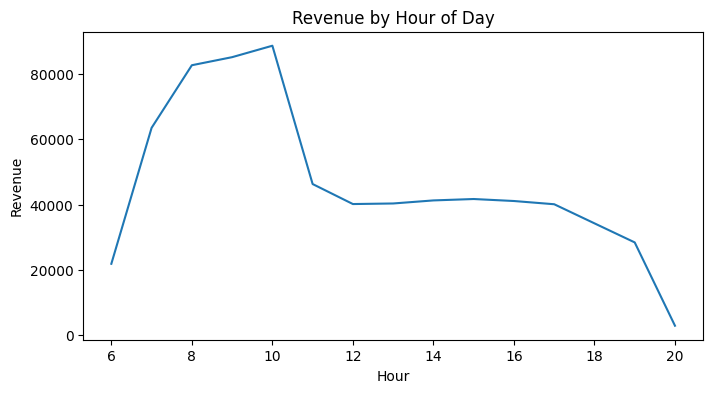

In [8]:
#Line chart - sales volume over time (hourly trends)
hourly_sales = coffee_df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values)
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

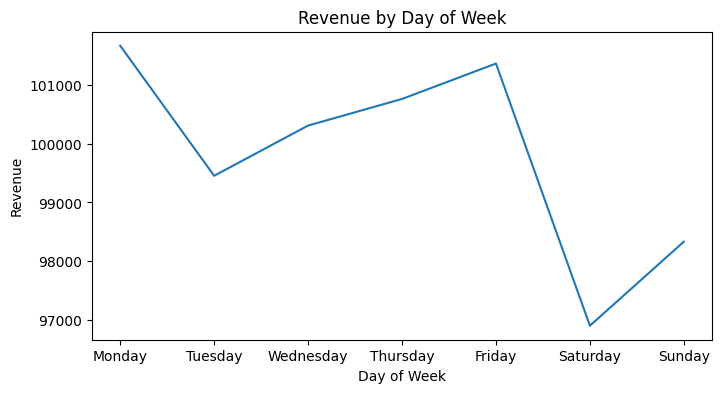

In [9]:
#Line chart - sales volume over time (weekly trends)
#Correct order of days first so it is not alphabetical
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
coffee_df['day_of_week'] = pd.Categorical(coffee_df['day_of_week'], categories=days_order, ordered=True)

day_of_week_sales = coffee_df.groupby('day_of_week')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=day_of_week_sales.index, y=day_of_week_sales.values)
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.show()

## Sales by Month

In [10]:
# Determine unique values of months
month_values = coffee_df['month'].unique()
print(month_values)

['January' 'February' 'March' 'April' 'May' 'June']


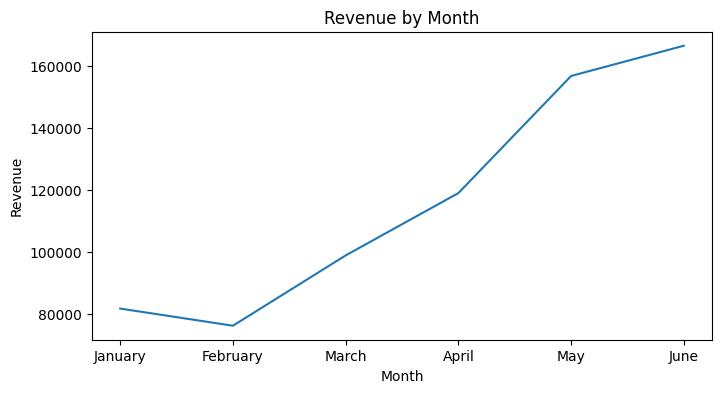

In [11]:
# Line chart - sales volume over time (monthly trends)
# Correct order of months first so it is not alphabetical
months_order = ['January', 'February', 'March', 'April', 'May', 'June']
coffee_df['month'] = pd.Categorical(coffee_df['month'], categories=months_order, ordered=True)

monthly_sales = coffee_df.groupby('month')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Sales by Day vs Hour

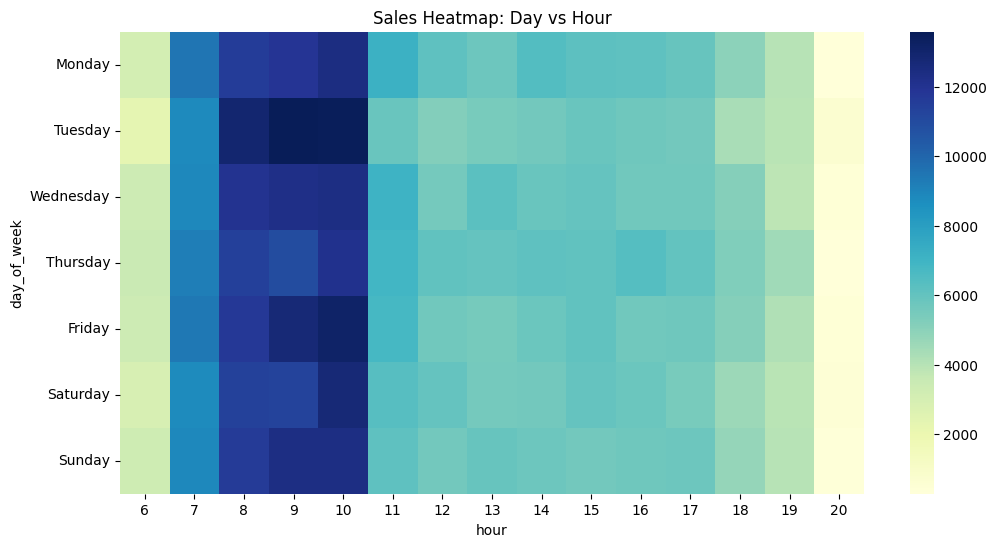

In [12]:
# Heatmap - sales by hour vs day of week... maybe could help create staffing guides
pivot = coffee_df.pivot_table(values='revenue', index='day_of_week', columns='hour', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Sales Heatmap: Day vs Hour")
plt.show()

## Best selling products and types

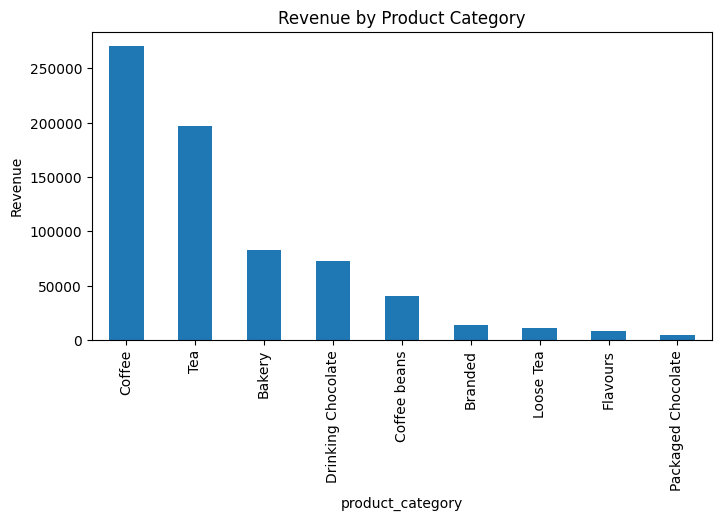

In [13]:
# Products with best sales
product_sales = coffee_df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4))
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()

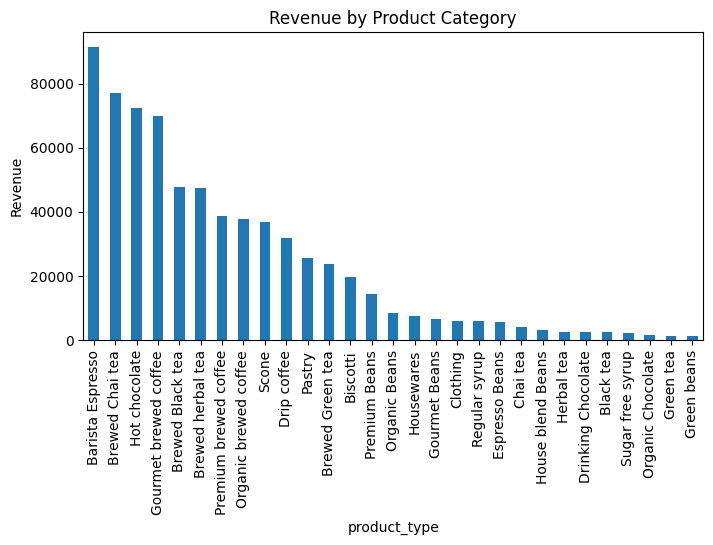

In [14]:
# Products types with best sales
product_sales = coffee_df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4))
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()

## Product Trends by Month

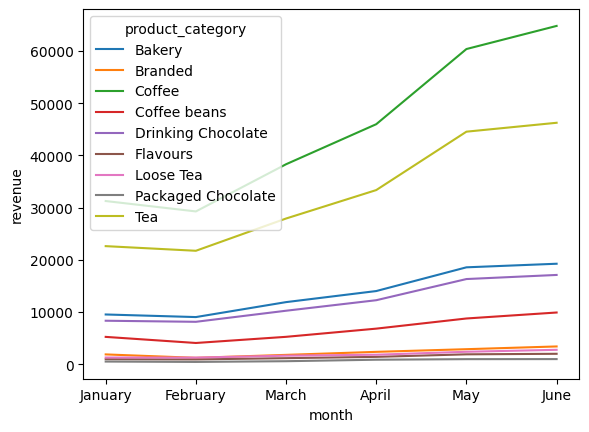

In [15]:
# Investigate any product trends that may vary by month
product_trends = coffee_df.groupby(['month','product_category'], observed=False)['revenue'].sum().reset_index()
sns.lineplot(data=product_trends, x='month', y='revenue', hue='product_category')
plt.show()

## Revenue by Location

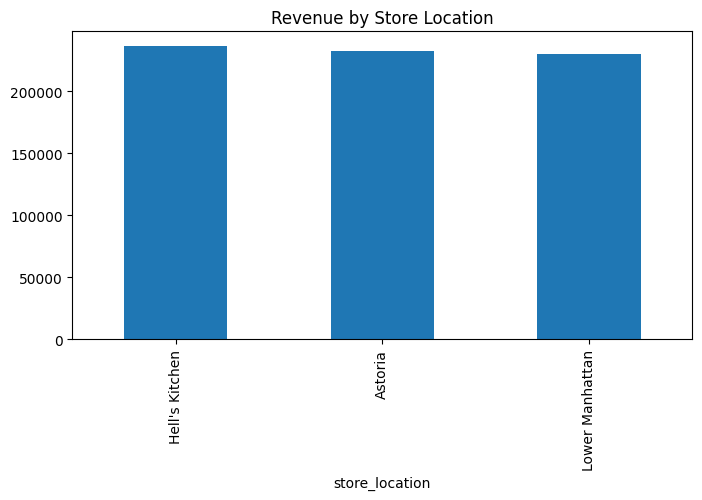

In [16]:
# Compare store performances based on revenue
store_sales = coffee_df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
store_sales.plot(kind='bar', figsize=(8,4), title="Revenue by Store Location")
plt.show()

# Individual Locations

In [17]:
# Findings per locations
lower_manhattan_df = coffee_df[coffee_df['store_location'] == 'Lower Manhattan'] # blue
hells_kitchen_df = coffee_df[coffee_df['store_location'] == "Hell's Kitchen"] # orange
astoria_df = coffee_df[coffee_df['store_location'] == 'Astoria'] # green

## Sales by Hour

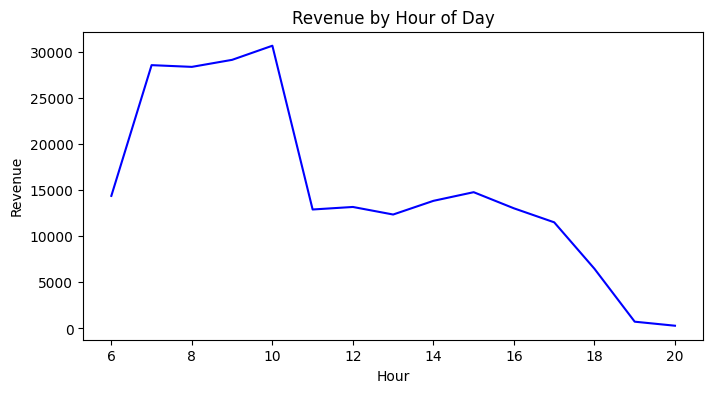

In [18]:
# Line chart - sales volume over time (hourly trends) - LOWER MANHATTAN
hourly_sales = lower_manhattan_df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, color='blue')
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

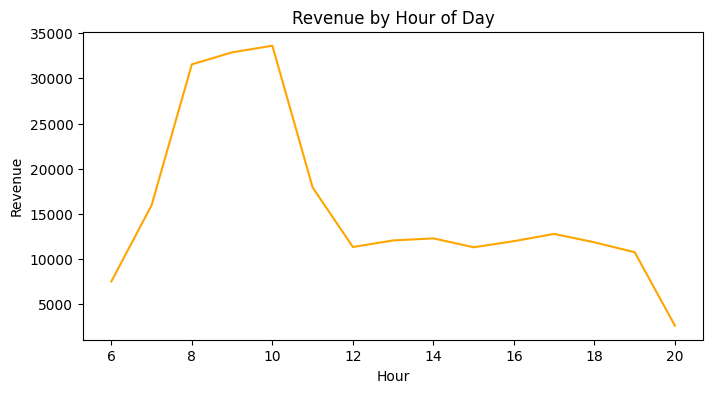

In [19]:
# Line chart - sales volume over time (hourly trends) - HELL'S KITCHEN
hourly_sales = hells_kitchen_df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, color='orange')
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

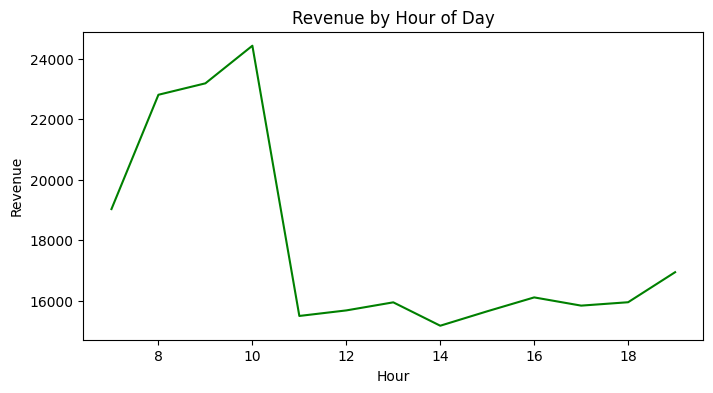

In [20]:
# Line chart - sales volume over time (hourly trends) - ASTORIA
hourly_sales = astoria_df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, color='green')
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

## Sales by Week

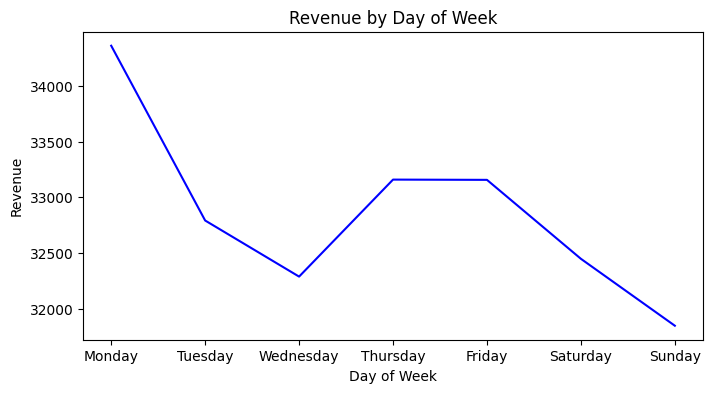

In [21]:
# Line chart - sales volume over time (weekly trends) - LOWER MANHATTAN
day_of_week_sales = lower_manhattan_df.groupby('day_of_week')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=day_of_week_sales.index, y=day_of_week_sales.values, color='blue')
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.show()

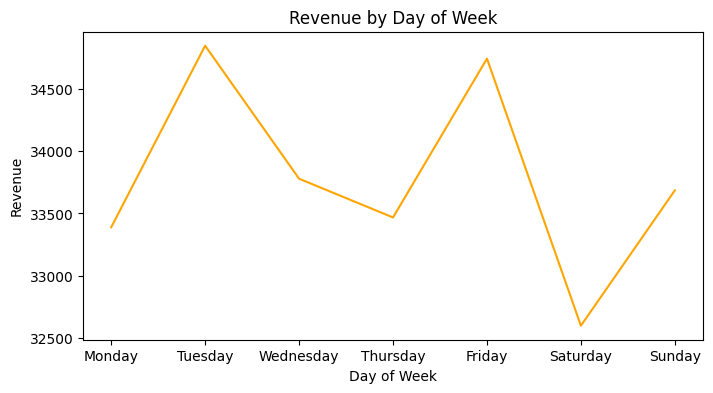

In [22]:
# Line chart - sales volume over time (weekly trends) - HELLS KITCHEN
day_of_week_sales = hells_kitchen_df.groupby('day_of_week')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=day_of_week_sales.index, y=day_of_week_sales.values, color='orange')
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.show()

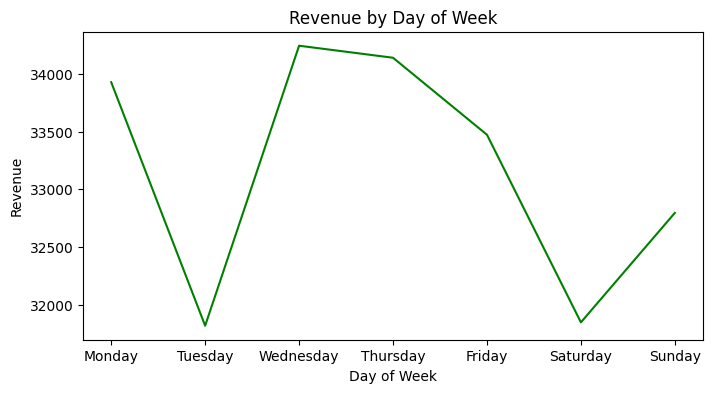

In [23]:
# Line chart - sales volume over time (weekly trends) - ASTORIA
day_of_week_sales = astoria_df.groupby('day_of_week')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=day_of_week_sales.index, y=day_of_week_sales.values, color='green')
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.show()

## Sales by Day vs Hour

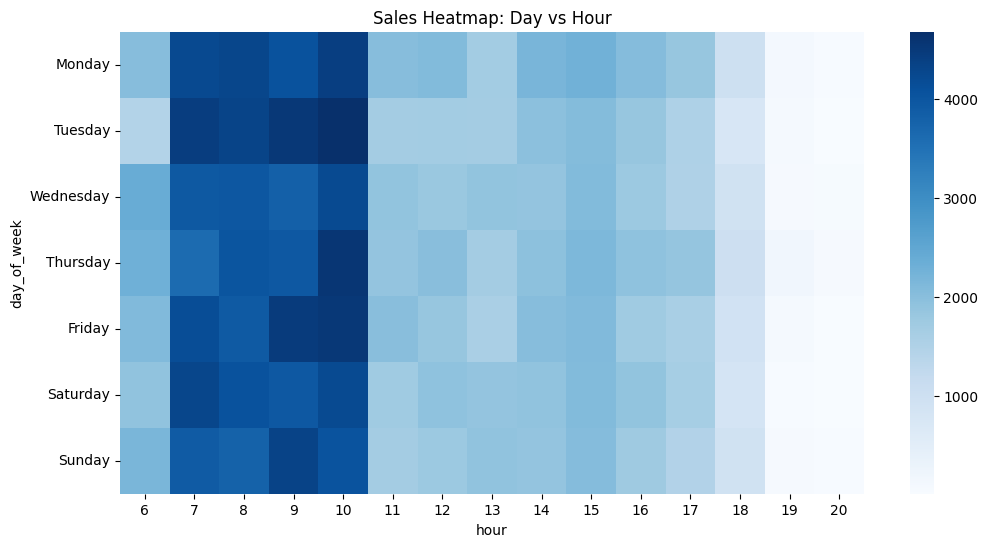

In [24]:
# Heatmap - sales by hour vs day of week... - LOWER MANHATTAN
pivot = lower_manhattan_df.pivot_table(values='revenue', index='day_of_week', columns='hour', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Blues")
plt.title("Sales Heatmap: Day vs Hour")
plt.show()

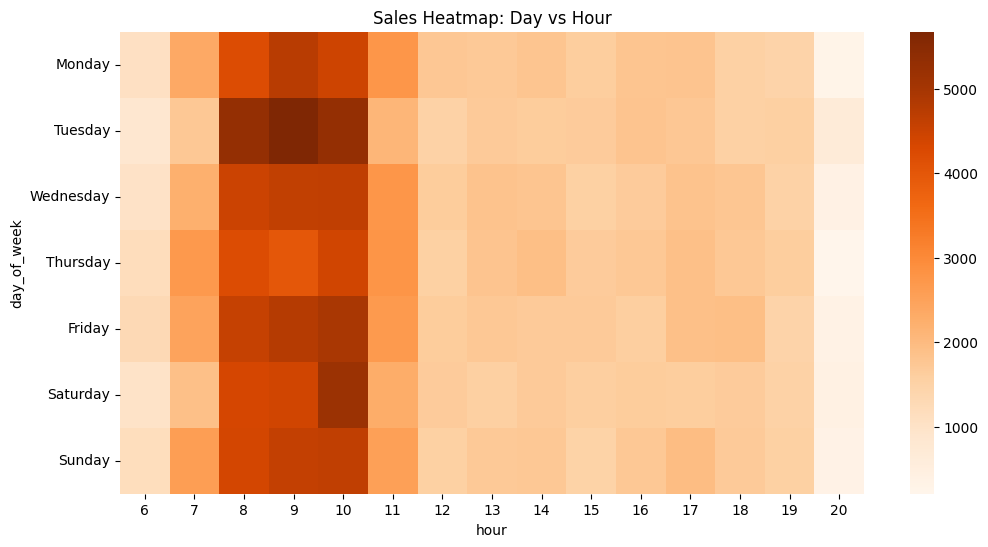

In [25]:
# Heatmap - sales by hour vs day of week... - HELL'S KITCHEN
pivot = hells_kitchen_df.pivot_table(values='revenue', index='day_of_week', columns='hour', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Oranges")
plt.title("Sales Heatmap: Day vs Hour")
plt.show()

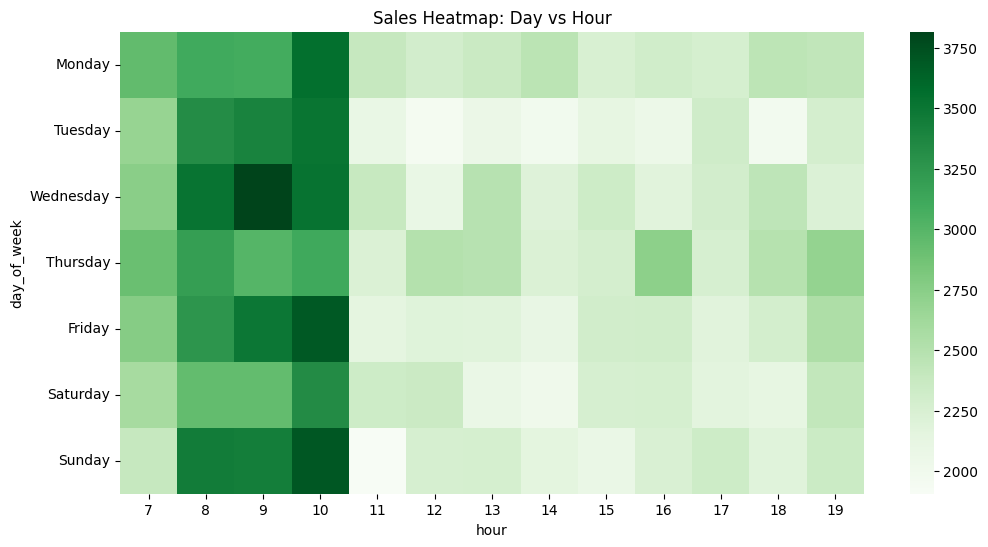

In [26]:
# Heatmap - sales by hour vs day of week... - ASTORIA
pivot = astoria_df.pivot_table(values='revenue', index='day_of_week', columns='hour', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Greens")
plt.title("Sales Heatmap: Day vs Hour")
plt.show()

## Best selling products and types

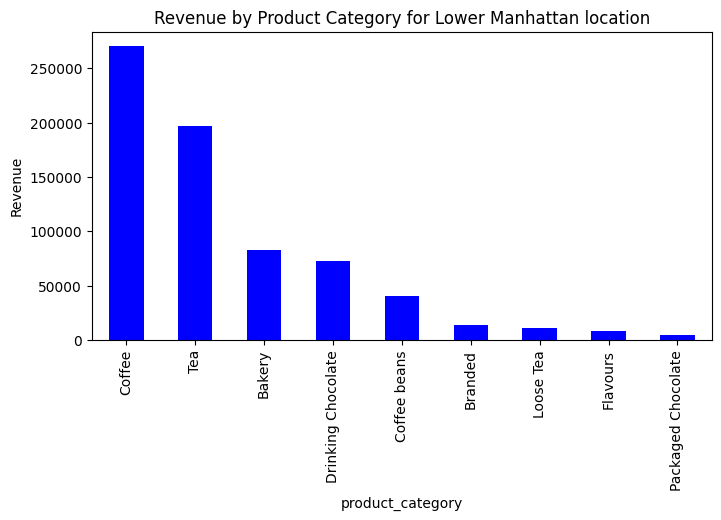

In [27]:
# Products with best sales - LOWER MANHATTAN
product_sales = coffee_df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='blue')
plt.title("Revenue by Product Category for Lower Manhattan location")
plt.ylabel("Revenue")
plt.show()

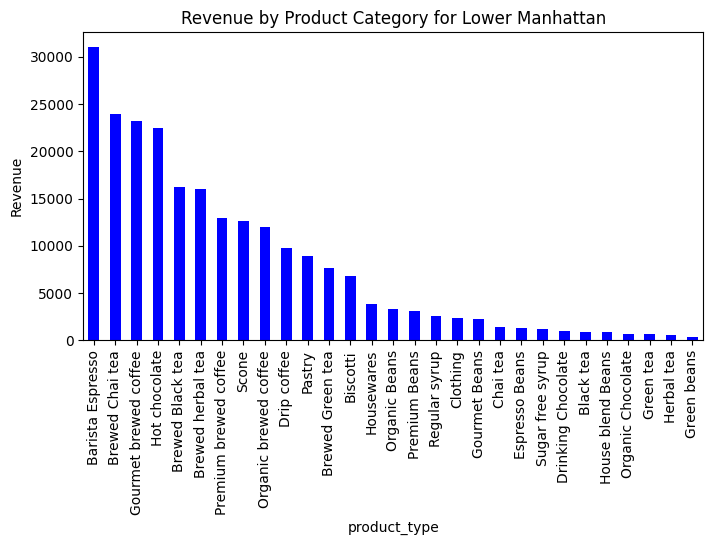

In [28]:
# Products types with best sales - LOWER MANHATTAN
product_sales = lower_manhattan_df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='Blue')
plt.title("Revenue by Product Category for Lower Manhattan")
plt.ylabel("Revenue")
plt.show()

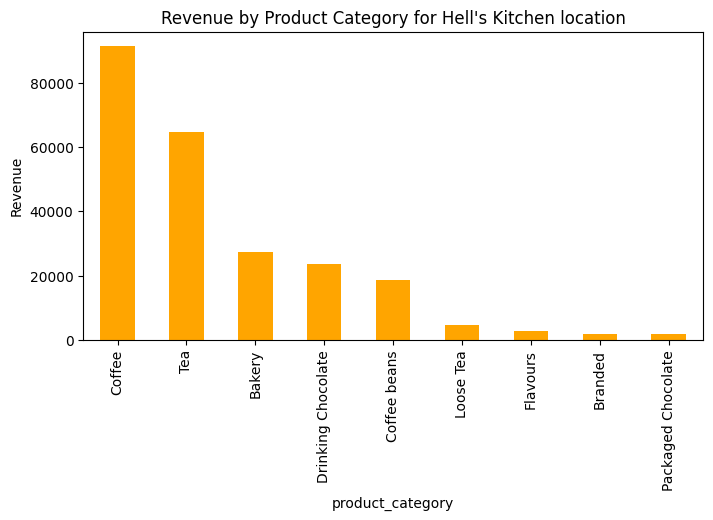

In [29]:
# Products with best sales - HELL'S KITCHEN
product_sales = hells_kitchen_df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='orange')
plt.title("Revenue by Product Category for Hell's Kitchen location")
plt.ylabel("Revenue")
plt.show()

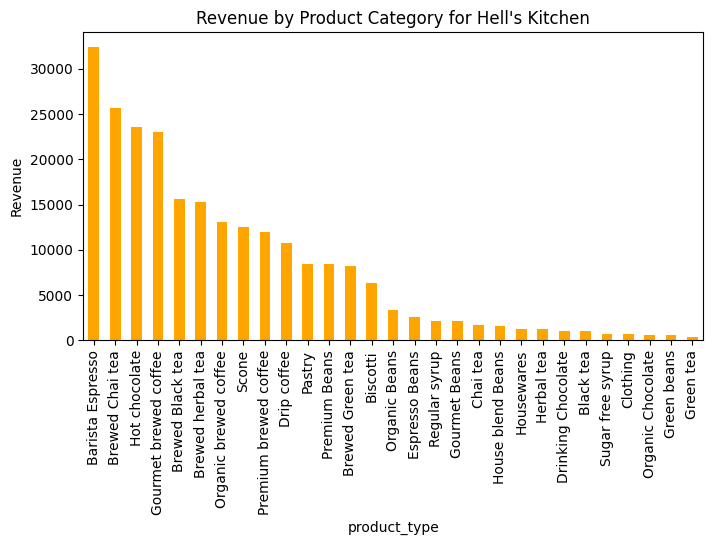

In [30]:
# Products types with best sales - LOWER MANHATTAN
product_sales = hells_kitchen_df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='Orange')
plt.title("Revenue by Product Category for Hell's Kitchen")
plt.ylabel("Revenue")
plt.show()

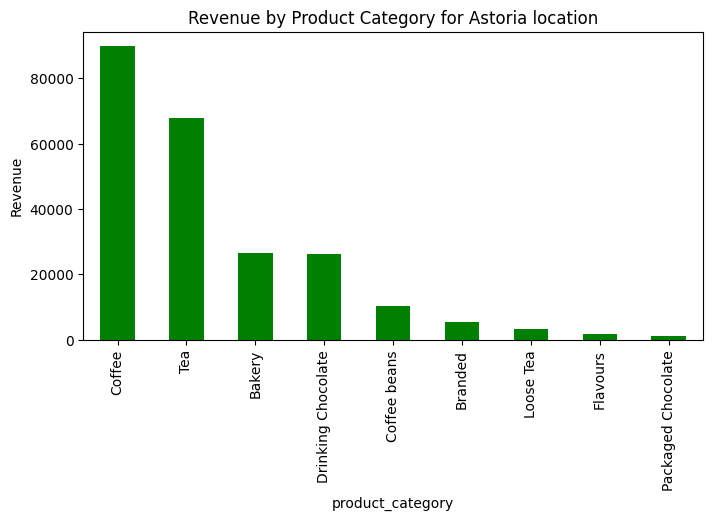

In [31]:
# Products with best sales - ASTORIA
product_sales = astoria_df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='green')
plt.title("Revenue by Product Category for Astoria location")
plt.ylabel("Revenue")
plt.show()

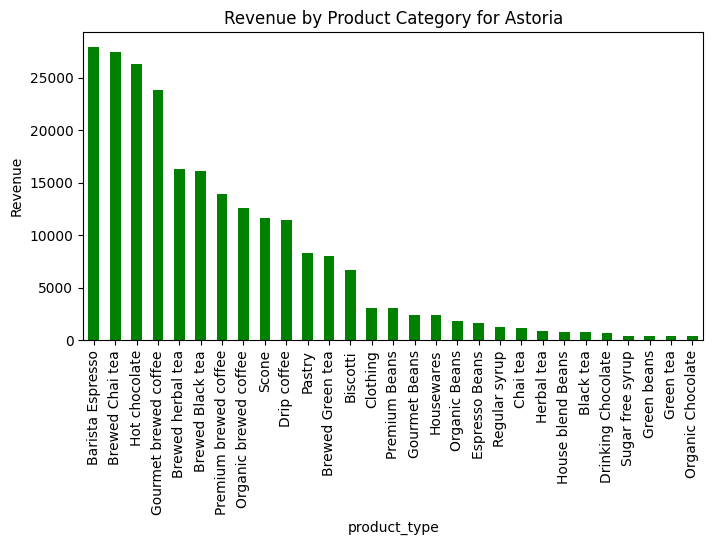

In [32]:
# Products types with best sales - ASTORIA
product_sales = astoria_df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='Green')
plt.title("Revenue by Product Category for Astoria")
plt.ylabel("Revenue")
plt.show()

## Product Trends by Month

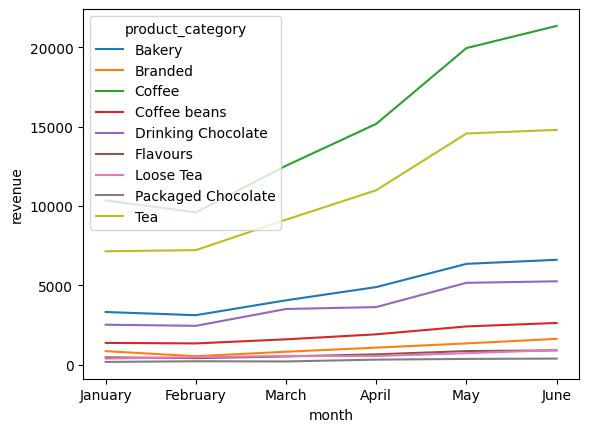

In [33]:
# Investigate any product trends that may vary by month - LOWER MANHATTAN
product_trends = lower_manhattan_df.groupby(['month','product_category'], observed=False)['revenue'].sum().reset_index()
sns.lineplot(data=product_trends, x='month', y='revenue', hue='product_category', color='blue')
plt.show()

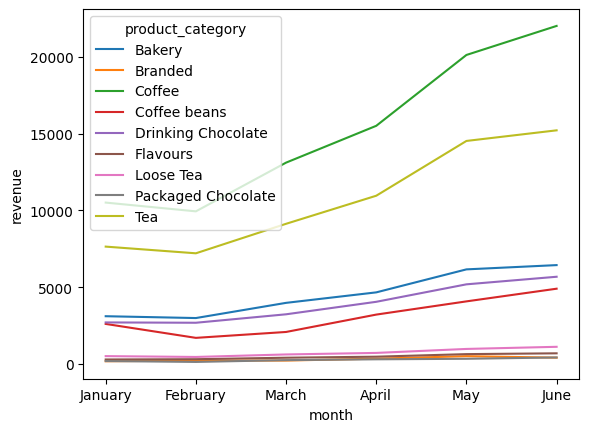

In [34]:
# Investigate any product trends that may vary by month - HELL'S KITCHEN
product_trends = hells_kitchen_df.groupby(['month','product_category'], observed=False)['revenue'].sum().reset_index()
sns.lineplot(data=product_trends, x='month', y='revenue', hue='product_category', color='orange')
plt.show()

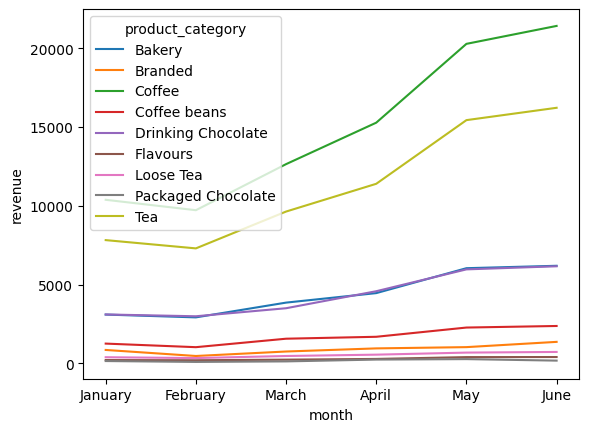

In [35]:
# Investigate any product trends that may vary by month - ASTORIA
product_trends = astoria_df.groupby(['month','product_category'], observed=False)['revenue'].sum().reset_index()
sns.lineplot(data=product_trends, x='month', y='revenue', hue='product_category', color='green')
plt.show()

# Market Basket Association
What items do customers tend to buy together?

In [36]:
# Run association rules for product by category, type, and detail!
# Create function for generating association rules to be applied by level (level_col)
def generate_association_rules(coffee_df, level_col, min_support=0.01, metric="confidence", min_threshold=0.1, top_n=10): # adjusted min_support, tried metric "lift"

    # Create a basket
    basket = (coffee_df.groupby(['transaction_id', level_col])['transaction_qty'].sum().unstack().fillna(0))

    # Convert to binary (1 if purchased, 0 if did not purchase)
    basket = basket.applymap(lambda x: 1 if x > 0 else 0)

    # Apply apriori
    frequent_itemsets = apriori(basket, min_support=min_support, use_colnames=True)

    # Generate the association rules
    rules = association_rules(frequent_itemsets, metric=metric, min_threshold=min_threshold)

    # Sort by chosen metric (in this case, lift)
    rules = rules.sort_values(metric, ascending=False).head(top_n)

    return rules

In [37]:
# Generate association rules by product_category
rules_cat = generate_association_rules(coffee_df, "product_category", min_support=0.02, top_n=10)
print(rules_cat[['antecedents','consequents','support','confidence','lift']])

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [38]:
# Generate association rules by product_type
rules_type = generate_association_rules(coffee_df, "product_type", min_support=0.01, top_n=10)
print(rules_type[['antecedents','consequents','support','confidence','lift']])

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [39]:
# Generate association rules by product_detail
rules_detail = generate_association_rules(coffee_df, "product_detail", min_support=0.005, top_n=10)
print(rules_detail[['antecedents','consequents','support','confidence','lift']])

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


# **DATA PRE-PROCESSING AND SPLITTING**

In [40]:
#BOOTSTRAP: make sure `df` exists and has the basics

if 'df' in globals():
    pass 
elif 'coffee_df' in globals():
    df = coffee_df.copy()
elif 'model_df' in globals():
    df = model_df.copy()
else:
    raise RuntimeError("`df` is not defined. Load your data first (into `coffee_df` or `df`).")

#Ensure types & convenience columns (idempotent)
if 'transaction_date' in df.columns:
    df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
if 'transaction_time' in df.columns:
    df['transaction_time'] = pd.to_datetime(df['transaction_time'].astype(str), errors='coerce').dt.time

if 'revenue' not in df.columns and {'transaction_qty','unit_price'}.issubset(df.columns):
    df['revenue'] = df['transaction_qty'] * df['unit_price']

if 'hour' not in df.columns:
    if 'transaction_time' in df.columns:
        df['hour'] = pd.to_datetime(df['transaction_time'].astype(str), errors='coerce').dt.hour
    elif 'transaction_date' in df.columns:
        df['hour'] = df['transaction_date'].dt.hour

if 'day_of_week' not in df.columns and 'transaction_date' in df.columns:
    df['day_of_week'] = df['transaction_date'].dt.day_name()
if 'month' not in df.columns and 'transaction_date' in df.columns:
    df['month'] = df['transaction_date'].dt.month_name()

#Hourly timestamp (top of hour)
if 'ts' not in df.columns and 'transaction_date' in df.columns and 'hour' in df.columns:
    df['ts'] = pd.to_datetime(df['transaction_date'].dt.strftime('%Y-%m-%d') + ' ' + df['hour'].astype(str) + ':00:00')

print("df is ready:", df.shape)
print("Columns sample:", list(df.columns)[:20])

df is ready: (149116, 16)
Columns sample: ['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'hour', 'day_of_week', 'month', 'revenue', 'ts']


## **Feature engineering (ratios, calendar flags, rolling lags**

In [41]:
#MAP actual columns
def pick(colnames, candidates):
    for c in candidates:
        if c in colnames:
            return c
    return None

cols = df.columns

COL_PRICE = pick(cols, ['unit_price','price','item_price','Product Price','Unit Price'])
COL_QTY   = pick(cols, ['transaction_qty','quantity','qty','Item Qty','Quantity'])
COL_DATE  = pick(cols, ['transaction_date','date','Order Date','order_date'])
COL_TIME  = pick(cols, ['transaction_time','time','Order Time','order_time'])
COL_LOC   = pick(cols, ['store_location','location','store','Store','store_name'])
COL_CAT   = pick(cols, ['product_category','category','Product Category'])
COL_TYPE  = pick(cols, ['product_type','type','Product Type'])
COL_DET   = pick(cols, ['product_detail','product','item','Product','Item'])

print("Detected columns ->",
      dict(price=COL_PRICE, qty=COL_QTY, date=COL_DATE, time=COL_TIME,
           location=COL_LOC, category=COL_CAT, ptype=COL_TYPE, detail=COL_DET))

Detected columns -> {'price': 'unit_price', 'qty': 'transaction_qty', 'date': 'transaction_date', 'time': 'transaction_time', 'location': 'store_location', 'category': 'product_category', 'ptype': 'product_type', 'detail': 'product_detail'}


In [42]:
#MAP actual columns
def pick(colnames, candidates):
    for c in candidates:
        if c in colnames:
            return c
    return None

cols = df.columns

COL_PRICE = pick(cols, ['unit_price','price','item_price','Product Price','Unit Price'])
COL_QTY   = pick(cols, ['transaction_qty','quantity','qty','Item Qty','Quantity'])
COL_DATE  = pick(cols, ['transaction_date','date','Order Date','order_date'])
COL_TIME  = pick(cols, ['transaction_time','time','Order Time','order_time'])
COL_LOC   = pick(cols, ['store_location','location','store','Store','store_name'])
COL_CAT   = pick(cols, ['product_category','category','Product Category'])
COL_TYPE  = pick(cols, ['product_type','type','Product Type'])
COL_DET   = pick(cols, ['product_detail','product','item','Product','Item'])

print("Detected columns ->",
      dict(price=COL_PRICE, qty=COL_QTY, date=COL_DATE, time=COL_TIME,
           location=COL_LOC, category=COL_CAT, ptype=COL_TYPE, detail=COL_DET))

#minimal guards
for need, name in [('price',COL_PRICE), ('qty',COL_QTY), ('date',COL_DATE)]:
    if name is None:
        raise ValueError(f"Could not find a column for {need}. Please rename in the mapping above.")

#core convenience columns
# revenue
if 'revenue' not in df:
    df['revenue'] = df[COL_QTY] * df[COL_PRICE]

# datetime parts
if COL_DATE not in df.select_dtypes(include=['datetime64[ns]']).columns:
    try:
        df[COL_DATE] = pd.to_datetime(df[COL_DATE])
    except Exception:
        
        df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors='coerce', infer_datetime_format=True)

if COL_TIME and (df[COL_TIME].dtype != 'O' and str(df[COL_TIME].dtype).startswith('datetime')) is False:
    try:
        df[COL_TIME] = pd.to_datetime(df[COL_TIME].astype(str), format='%H:%M:%S', errors='coerce').dt.time
    except Exception:
        df[COL_TIME] = pd.to_datetime(df[COL_TIME].astype(str), errors='coerce').dt.time

if 'hour' not in df:
    if COL_TIME in df and COL_TIME is not None:
        df['hour'] = pd.to_datetime(df[COL_TIME].astype(str), errors='coerce').dt.hour
    else:
        df['hour'] = df[COL_DATE].dt.hour

if 'day_of_week' not in df:
    df['day_of_week'] = df[COL_DATE].dt.day_name()

if 'month' not in df:
    df['month'] = df[COL_DATE].dt.month_name()

#outlier-capped copies (make only if missing)
def iqr_cap(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return s.clip(lower=lo, upper=hi)

if 'unit_price_cap' not in df and f'{COL_PRICE}_cap' not in df:
    df['unit_price_cap'] = iqr_cap(df[COL_PRICE])
    PRICE_CAP = 'unit_price_cap'
else:
    PRICE_CAP = 'unit_price_cap' if 'unit_price_cap' in df else f'{COL_PRICE}_cap'

if 'transaction_qty_cap' not in df and f'{COL_QTY}_cap' not in df:
    df['transaction_qty_cap'] = iqr_cap(df[COL_QTY])
    QTY_CAP = 'transaction_qty_cap'
else:
    QTY_CAP = 'transaction_qty_cap' if 'transaction_qty_cap' in df else f'{COL_QTY}_cap'

#calendar flags
if 'is_weekend' not in df:      df['is_weekend'] = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
if 'is_morning_peak' not in df: df['is_morning_peak'] = df['hour'].between(7,10).astype(int)
if 'is_lunch_peak' not in df:   df['is_lunch_peak']   = df['hour'].between(11,14).astype(int)

#ticket-level metrics
if 'items_per_ticket' not in df or 'spend_per_ticket' not in df:
    txn_agg = df.groupby('transaction_id', dropna=False).agg(
        items_per_ticket=(COL_QTY,'sum'),
        spend_per_ticket=('revenue','sum')
    ).reset_index()
    df = df.merge(txn_agg, on='transaction_id', how='left')

#store-hour lags/rollings
if COL_LOC is None:
    raise ValueError("Could not detect a store/location column. Update the mapping above.")

#per-row timestamp at top of the hour
if 'ts' not in df:
    df['ts'] = pd.to_datetime(df[COL_DATE].dt.strftime('%Y-%m-%d') + ' ' + df['hour'].astype(str) + ':00:00')

hourly = (
    df.groupby([COL_LOC,'ts'], as_index=False)
      .agg(hour_revenue=('revenue','sum'),
           hour_items=(COL_QTY,'sum'))
      .sort_values([COL_LOC,'ts'])
)

for lag in [1, 24, 24*7]:
    col = f'hour_revenue_lag_{lag}'
    if col not in hourly:
        hourly[col] = hourly.groupby(COL_LOC)['hour_revenue'].shift(lag)

if 'hour_revenue_rolling_24h_mean' not in hourly:
    hourly['hour_revenue_rolling_24h_mean'] = (
        hourly.groupby(COL_LOC)['hour_revenue'].shift(1).rolling(24).mean()
    )
if 'hour_revenue_rolling_7d_mean' not in hourly:
    hourly['hour_revenue_rolling_7d_mean'] = (
        hourly.groupby(COL_LOC)['hour_revenue'].shift(1).rolling(24*7).mean()
    )

#merge back (no duplicates)
merge_keys = [COL_LOC,'ts']
new_cols = [c for c in hourly.columns if c not in merge_keys]
df = df.merge(hourly, on=merge_keys, how='left', suffixes=('',''))

#popularity / relative price (only if columns exist)
for col in [c for c in [COL_CAT, COL_TYPE, COL_DET, COL_LOC] if c is not None]:
    freq_col = f'{col}_freq'
    if freq_col not in df:
        freq = df[col].value_counts(normalize=True)
        df[freq_col] = df[col].map(freq)

if COL_CAT is not None:
    if 'price_vs_cat_median' not in df:
        cat_med = df.groupby(COL_CAT)[PRICE_CAP].median()
        df['price_vs_cat_median'] = df[PRICE_CAP] / df[COL_CAT].map(cat_med).replace(0, np.nan)

print("Preprocessing/feature engineering synchronized with your actual columns.")

Detected columns -> {'price': 'unit_price', 'qty': 'transaction_qty', 'date': 'transaction_date', 'time': 'transaction_time', 'location': 'store_location', 'category': 'product_category', 'ptype': 'product_type', 'detail': 'product_detail'}
Preprocessing/feature engineering synchronized with your actual columns.


In [43]:
#Encoding (OHE for small-cardinality) + build model

from sklearn.preprocessing import OneHotEncoder

#small-cardinality categoricals: location/day/month
cat_small = [COL_LOC, 'day_of_week', 'month']

#OHE (handle old/new sklearn)
try:
    ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
except TypeError:
    ohe = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')

ohe_mat = ohe.fit_transform(df[cat_small])
ohe_cols = []
for c, cats in zip(cat_small, ohe.categories_):
    
    ohe_cols += [f"{c}_{v}" for v in cats[1:]]

ohe_df = pd.DataFrame(ohe_mat, columns=ohe_cols, index=df.index)

#keep frequency encodings created for larger-cardinality columns (category/type/detail/location)
model_df = pd.concat([df, ohe_df], axis=1)
print("OHE columns:", len(ohe_cols))

OHE columns: 13


In [44]:
#build items lags on the hourly frame (t-1, t-24, t-168) and merge back
hourly_extra = (
    df.groupby([COL_LOC, 'ts'], as_index=False)
      .agg(hour_items=('transaction_qty','sum'))
      .sort_values([COL_LOC,'ts'])
)

for lag in [1, 24, 24*7]:
    hourly_extra[f'hour_items_lag_{lag}'] = hourly_extra.groupby(COL_LOC)['hour_items'].shift(lag)

#merge lagged items (remove same-hour hour_items as a feature)
df = df.merge(
    hourly_extra[[COL_LOC,'ts','hour_items_lag_1','hour_items_lag_24','hour_items_lag_168']],
    on=[COL_LOC,'ts'], how='left'
)

In [45]:
#Scaling:

from sklearn.preprocessing import StandardScaler

#rebuild numeric_cols to include ONLY lagged items, not same-hour 'hour_items'
numeric_cols = [
    'unit_price_cap','transaction_qty_cap','items_per_ticket','spend_per_ticket',
    'hour_revenue_lag_1','hour_revenue_lag_24','hour_revenue_lag_168',
    'hour_revenue_rolling_24h_mean','hour_revenue_rolling_7d_mean',
    'product_category_freq','product_type_freq','product_detail_freq', f'{COL_LOC}_freq',
    'price_vs_cat_median',
    'hour_items_lag_1','hour_items_lag_24','hour_items_lag_168'
]

for c in numeric_cols:
    if c not in model_df.columns:
        model_df[c] = 0.0
model_df[numeric_cols] = model_df[numeric_cols].fillna(0.0)

#refit scaler for clarity after adding new cols

scaler = StandardScaler()
model_df[[f"{c}_z" for c in numeric_cols]] = scaler.fit_transform(model_df[numeric_cols])

## **True forecast: predict next hour revenue**

In [46]:
#make the target one hour ahead per store
#one row per store-hour, with t+1 target
store_hour = (
    model_df.dropna(subset=['hour_revenue'])
            .drop_duplicates(subset=[COL_LOC, 'ts'])
            .sort_values([COL_LOC,'ts'])
            .copy()
)

store_hour['hour_revenue_tplus1'] = store_hour.groupby(COL_LOC)['hour_revenue'].shift(-1)
store_hour = store_hour.dropna(subset=['hour_revenue_tplus1'])

#features = scaled numerics (including *lagged* items), OHE, and calendar flags
feature_cols = [c for c in store_hour.columns if c.endswith('_z')] + ohe_cols + [
    'is_weekend','is_morning_peak','is_lunch_peak'
]

#ensuring we DO NOT have same-hour 'hour_items_z'
feature_cols = [c for c in feature_cols if c != 'hour_items_z']

target_col = 'hour_revenue_tplus1'

#verify no same-hour items
print([c for c in feature_cols if 'hour_items' in c])

['hour_items_lag_1_z', 'hour_items_lag_24_z', 'hour_items_lag_168_z']


## **Time-aware 70/15/15 split + RF:**

In [47]:
#Time-aware 70/15/15 split
ts_sorted = store_hour['ts'].sort_values().unique()
cut1 = ts_sorted[int(len(ts_sorted) * 0.70)]
cut2 = ts_sorted[int(len(ts_sorted) * 0.85)]

train_idx = store_hour['ts'] <= cut1
val_idx   = (store_hour['ts'] > cut1) & (store_hour['ts'] <= cut2)
test_idx  = store_hour['ts'] > cut2

X_train, y_train = store_hour.loc[train_idx, feature_cols], store_hour.loc[train_idx, target_col]
X_val,   y_val   = store_hour.loc[val_idx,   feature_cols], store_hour.loc[val_idx,   target_col]
X_test,  y_test  = store_hour.loc[test_idx,  feature_cols], store_hour.loc[test_idx,  target_col]

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

def eval_set(name, X, y):
    p = rf.predict(X)
    mae = mean_absolute_error(y, p)
    rmse = mean_squared_error(y, p, squared=False)
    print(f"{name:>5} -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f}")
    return mae, rmse

print("\nRandomForest t+1 forecast (target = next-hour revenue)")
eval_set("Train", X_train, y_train)
eval_set("  Val", X_val, y_val)
eval_set(" Test", X_test, y_test)

import pandas as pd
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
imp.to_frame("importance")


RandomForest t+1 forecast (target = next-hour revenue)
Train -> MAE: 14.76 | RMSE: 22.97
  Val -> MAE: 63.61 | RMSE: 82.56
 Test -> MAE: 56.37 | RMSE: 84.26


,importance
hour_revenue_lag_24_z,0.144813
is_morning_peak,0.133290
hour_revenue_lag_1_z,0.128668
hour_revenue_rolling_7d_mean_z,0.115792
hour_revenue_rolling_24h_mean_z,0.096992
hour_revenue_lag_168_z,0.069590
month_May,0.050710
product_detail_freq_z,0.044408
spend_per_ticket_z,0.036584
product_type_freq_z,0.027559


In [48]:
#Remove "now" fields; add lagged spend-per tix

#build store-hour mean spend_per_ticket and its lags; not using same-hour versions as features
spend_hourly = (
    df.groupby([COL_LOC, 'ts'], as_index=False)
      .agg(spend_per_ticket_hour=('spend_per_ticket','mean'))
      .sort_values([COL_LOC,'ts'])
)

for lag in [1, 24, 24*7]:
    spend_hourly[f'spend_per_ticket_hour_lag_{lag}'] = (
        spend_hourly.groupby(COL_LOC)['spend_per_ticket_hour'].shift(lag)
    )

df = df.merge(
    spend_hourly[[COL_LOC,'ts','spend_per_ticket_hour_lag_1',
                  'spend_per_ticket_hour_lag_24','spend_per_ticket_hour_lag_168']],
    on=[COL_LOC,'ts'], how='left'
)

#add lagged items
items_hourly = (
    df.groupby([COL_LOC, 'ts'], as_index=False)
      .agg(hour_items=('transaction_qty','sum'))
      .sort_values([COL_LOC,'ts'])
)
for lag in [1, 24, 24*7]:
    items_hourly[f'hour_items_lag_{lag}'] = items_hourly.groupby(COL_LOC)['hour_items'].shift(lag)

df = df.merge(
    items_hourly[[COL_LOC,'ts','hour_items_lag_1','hour_items_lag_24','hour_items_lag_168']],
    on=[COL_LOC,'ts'], how='left'
)

In [49]:
#update scaled numeric list to include only lagged versions (no same-hour hour_items or spend_per_ticket):

numeric_cols = [
    'unit_price_cap','transaction_qty_cap','items_per_ticket',      # ticket metrics ok
    'hour_revenue_lag_1','hour_revenue_lag_24','hour_revenue_lag_168',
    'hour_revenue_rolling_24h_mean','hour_revenue_rolling_7d_mean',
    'product_category_freq','product_type_freq','product_detail_freq', f'{COL_LOC}_freq',
    'price_vs_cat_median',
    'hour_items_lag_1','hour_items_lag_24','hour_items_lag_168',
    'spend_per_ticket_hour_lag_1','spend_per_ticket_hour_lag_24','spend_per_ticket_hour_lag_168'
]

for c in numeric_cols:
    if c not in model_df.columns:
        model_df[c] = 0.0
model_df[numeric_cols] = model_df[numeric_cols].fillna(0.0)

scaler = StandardScaler()
model_df[[f"{c}_z" for c in numeric_cols]] = scaler.fit_transform(model_df[numeric_cols])

In [50]:
##cyclical encodings for hour & day-of-week

if 'ts' not in model_df.columns:
    model_df['ts'] = pd.to_datetime(model_df[COL_DATE].dt.strftime('%Y-%m-%d') + ' ' + model_df['hour'].astype(str) + ':00:00')
else:
    model_df['ts'] = pd.to_datetime(model_df['ts'])

#hour-of-day from ts (0..23)
model_df['hour_num'] = model_df['ts'].dt.hour.astype(int)
model_df['hour_sin'] = np.sin(2 * np.pi * model_df['hour_num'] / 24.0)
model_df['hour_cos'] = np.cos(2 * np.pi * model_df['hour_num'] / 24.0)

#day-of-week from ts (Monday=0..Sunday=6)
model_df['dow_idx'] = model_df['ts'].dt.dayofweek.astype(int)
model_df['dow_sin'] = np.sin(2 * np.pi * model_df['dow_idx'] / 7.0)
model_df['dow_cos'] = np.cos(2 * np.pi * model_df['dow_idx'] / 7.0)

In [51]:
#holiday flag

from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=model_df['ts'].min(), end=model_df['ts'].max())
model_df['is_holiday'] = model_df['ts'].dt.normalize().isin(holidays).astype(int)

In [52]:
#Store × hour interactions

store_ohe_cols = [c for c in ohe_cols if c.startswith(COL_LOC + '_')]

#create interactions: store_dummies × (hour_sin, hour_cos)
interaction_cols = []
for s in store_ohe_cols:
    for base in ['hour_sin','hour_cos']:
        col = f'{s}__{base}'
        model_df[col] = model_df[s] * model_df[base]
        interaction_cols.append(col)

print(f"Added {len(interaction_cols)} store×hour interaction features.")

Added 4 store×hour interaction features.


## **Rebuild t+1 dataset with new features**

In [53]:
#one row per store-hour
store_hour = (
    model_df.dropna(subset=['hour_revenue'])
            .drop_duplicates(subset=[COL_LOC,'ts'])
            .sort_values([COL_LOC,'ts'])
            .copy()
)

#t+1 target
store_hour['hour_revenue_tplus1'] = store_hour.groupby(COL_LOC)['hour_revenue'].shift(-1)
store_hour = store_hour.dropna(subset=['hour_revenue_tplus1'])

#feature set
feature_cols = (
    [c for c in store_hour.columns if c.endswith('_z')] +    #scaled numerics (lags/rollings/lagged items/spend)
    ohe_cols +                                               #OHEs
    ['is_weekend','is_morning_peak','is_lunch_peak',         #binary time flags
     'hour_sin','hour_cos','dow_sin','dow_cos',              #cyclical encodings
     'is_holiday'] +                                         #holiday flag
    interaction_cols                                         #store*hour interactions
)

#Explicitly any same-hour "now" proxies
feature_cols = [c for c in feature_cols if c not in ['hour_items_z','spend_per_ticket_z']]

#time-aware 70/15/15 split by ts
ts_sorted = store_hour['ts'].sort_values().unique()
cut1 = ts_sorted[int(len(ts_sorted) * 0.70)]
cut2 = ts_sorted[int(len(ts_sorted) * 0.85)]

train_idx = store_hour['ts'] <= cut1
val_idx   = (store_hour['ts'] > cut1) & (store_hour['ts'] <= cut2)
test_idx  = store_hour['ts'] > cut2

X_train, y_train = store_hour.loc[train_idx, feature_cols], store_hour.loc[train_idx, 'hour_revenue_tplus1']
X_val,   y_val   = store_hour.loc[val_idx,   feature_cols], store_hour.loc[val_idx,   'hour_revenue_tplus1']
X_test,  y_test  = store_hour.loc[test_idx,  feature_cols], store_hour.loc[test_idx,  'hour_revenue_tplus1']

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Shapes: (4776, 44) (1048, 44) (1036, 44)


## **XGBoost w/ early stopping**

In [54]:
def evaluate_preds(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    print(f"{name:>5} -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f}")
    return mae, rmse

try:
    from xgboost import XGBRegressor
    model = XGBRegressor(
        n_estimators=3000,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        tree_method="hist",
        n_jobs=-1
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        verbose=False,
        early_stopping_rounds=200
    )
    print("Model: XGBoost (best_iteration =", model.best_iteration, ")")
except Exception as e:
    print("XGBoost not available, using GradientBoostingRegressor instead.", e)
    from sklearn.ensemble import GradientBoostingRegressor
    model = GradientBoostingRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=3, random_state=42
    ).fit(X_train, y_train)

#evaluate
print("\n=== Next-hour revenue forecast (XGB/GBM) ===")
evaluate_preds("Train", y_train, model.predict(X_train))
evaluate_preds("  Val", y_val,   model.predict(X_val))
evaluate_preds(" Test", y_test,  model.predict(X_test))

XGBoost not available, using GradientBoostingRegressor instead. No module named 'xgboost'

=== Next-hour revenue forecast (XGB/GBM) ===
Train -> MAE: 26.60 | RMSE: 36.36
  Val -> MAE: 51.91 | RMSE: 72.49
 Test -> MAE: 60.15 | RMSE: 86.39


(np.float64(60.14797837636458), np.float64(86.39076266474459))

In [55]:
#log target variable

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

try:
    from xgboost import XGBRegressor
    model_log = XGBRegressor(
        n_estimators=3000, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=42, tree_method="hist", n_jobs=-1
    )
    model_log.fit(
        X_train, y_train_log,
        eval_set=[(X_val, y_val_log)],
        eval_metric="rmse",
        verbose=False,
        early_stopping_rounds=200
    )
    print("Model(Log): XGBoost (best_iteration =", model_log.best_iteration, ")")
except Exception:
    from sklearn.ensemble import GradientBoostingRegressor
    model_log = GradientBoostingRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=3, random_state=42
    ).fit(X_train, y_train_log)

#back-transform predictions to dollars
pred_train = np.expm1(model_log.predict(X_train))
pred_val   = np.expm1(model_log.predict(X_val))
pred_test  = np.expm1(model_log.predict(X_test))

print("\n=== Next-hour revenue forecast with log target (back-transformed) ===")
evaluate_preds("Train", y_train, pred_train)
evaluate_preds("  Val", y_val,   pred_val)
evaluate_preds(" Test", y_test,  pred_test)


=== Next-hour revenue forecast with log target (back-transformed) ===
Train -> MAE: 26.36 | RMSE: 39.71
  Val -> MAE: 55.22 | RMSE: 80.66
 Test -> MAE: 67.34 | RMSE: 96.51


(np.float64(67.34108438395346), np.float64(96.51219616665587))

In [56]:
#per-store models

from collections import defaultdict
results = []

unique_stores = store_hour[COL_LOC].unique()
for store in unique_stores:
    mask = store_hour[COL_LOC] == store
    Xs, ys = store_hour.loc[mask, feature_cols], store_hour.loc[mask, 'hour_revenue_tplus1']

    #time split inside this store
    ts_s = store_hour.loc[mask, 'ts'].sort_values().unique()
    if len(ts_s) < 40:   # skip tiny series
        continue
    c1 = ts_s[int(len(ts_s)*0.70)]
    c2 = ts_s[int(len(ts_s)*0.85)]
    tr = store_hour.loc[mask, 'ts'] <= c1
    va = (store_hour.loc[mask, 'ts'] > c1) & (store_hour.loc[mask, 'ts'] <= c2)
    te = store_hour.loc[mask, 'ts'] > c2

    try:
        from xgboost import XGBRegressor
        m = XGBRegressor(
            n_estimators=2000, max_depth=6, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            random_state=42, tree_method="hist", n_jobs=-1
        )
        m.fit(Xs[tr], ys[tr], eval_set=[(Xs[va], ys[va])], eval_metric="rmse",
              verbose=False, early_stopping_rounds=150)
    except Exception:
        from sklearn.ensemble import GradientBoostingRegressor
        m = GradientBoostingRegressor(
            n_estimators=600, learning_rate=0.05, max_depth=3, random_state=42
        ).fit(Xs[tr], ys[tr])

    mae_tr, rmse_tr = evaluate_preds(f"{store} Train", ys[tr], m.predict(Xs[tr]))
    mae_va, rmse_va = evaluate_preds(f"{store}   Val", ys[va], m.predict(Xs[va]))
    mae_te, rmse_te = evaluate_preds(f"{store}  Test", ys[te], m.predict(Xs[te]))
    results.append((store, mae_va, rmse_va, mae_te, rmse_te))

#quick summary (Val/Test MAE per store)
store_summary = pd.DataFrame(results, columns=['store','val_mae','val_rmse','test_mae','test_rmse']).sort_values('test_mae')
store_summary

Astoria Train -> MAE: 17.82 | RMSE: 22.98
Astoria   Val -> MAE: 59.56 | RMSE: 73.39
Astoria  Test -> MAE: 47.09 | RMSE: 67.18
Hell's Kitchen Train -> MAE: 18.95 | RMSE: 25.79
Hell's Kitchen   Val -> MAE: 53.88 | RMSE: 73.47
Hell's Kitchen  Test -> MAE: 50.56 | RMSE: 81.06
Lower Manhattan Train -> MAE: 17.30 | RMSE: 22.28
Lower Manhattan   Val -> MAE: 52.08 | RMSE: 70.00
Lower Manhattan  Test -> MAE: 55.69 | RMSE: 73.78


,store,val_mae,val_rmse,test_mae,test_rmse
0,Astoria,59.555699,73.391718,47.092892,67.184182
1,Hell's Kitchen,53.880144,73.471169,50.563261,81.056576
2,Lower Manhattan,52.075726,69.996368,55.690512,73.782713


In [57]:
#confirm target column and units
store_hour[['hour_revenue', 'hour_revenue_tplus1']].describe().round(2)

,hour_revenue,hour_revenue_tplus1
count,6860.00,6860.00
mean,101.85,101.84
std,74.29,74.30
min,2.20,2.20
25%,51.74,51.70
50%,83.38,83.38
75%,129.26,129.26
max,846.00,846.00


In [58]:
#rough "orders" interpretation:
#   If average ticket is $X, then MAE dollars = MAE/X tickets.
avg_ticket = (df['spend_per_ticket'].mean())
print("Average ticket (approx $):", round(avg_ticket, 2))

test_mae_dollars = 60.15  # <- replacing with printed Test MAE
approx_orders = test_mae_dollars / avg_ticket if avg_ticket and avg_ticket > 0 else None
print("A Test MAE of ${:.0f} is roughly ≈ {:.1f} orders".format(test_mae_dollars, approx_orders))

Average ticket (approx $): 4.69
A Test MAE of $60 is roughly ≈ 12.8 orders


In [59]:
#Per-store view: translate each store's MAE into "orders"
avg_ticket = df['spend_per_ticket'].mean()
store_summary.assign(
    test_orders=lambda d: d['test_mae'] / avg_ticket
)[['store','test_mae','test_rmse','test_orders']].round(2)

,store,test_mae,test_rmse,test_orders
0,Astoria,47.09,67.18,10.05
1,Hell's Kitchen,50.56,81.06,10.79
2,Lower Manhattan,55.69,73.78,11.88


# **Modeling**

In [60]:
def eval_model(name, model, X_tr, y_tr, X_va, y_va, X_te, y_te):
    model.fit(X_tr, y_tr)
    def m(y, p): 
        return (r2_score(y,p), mean_absolute_error(y,p), mean_squared_error(y,p, squared=False))
    r2_tr, mae_tr, rmse_tr = m(y_tr, model.predict(X_tr))
    r2_va, mae_va, rmse_va = m(y_va, model.predict(X_va))
    r2_te, mae_te, rmse_te = m(y_te, model.predict(X_te))
    return {"model":name, "R2_val":r2_va, "MAE_val":mae_va, "RMSE_val":rmse_va,
            "R2_test":r2_te, "MAE_test":mae_te, "RMSE_test":rmse_te}

results = []
results += [eval_model("Ridge", Ridge(alpha=3.0), X_train, y_train, X_val, y_val, X_test, y_test)]
results += [eval_model("HistGBR", HistGradientBoostingRegressor(max_iter=2000, early_stopping=True, learning_rate=0.06, random_state=42),
                       X_train, y_train, X_val, y_val, X_test, y_test)]
pd.DataFrame(results).round(3).sort_values("MAE_test")

,model,R2_val,MAE_val,RMSE_val,R2_test,MAE_test,RMSE_test
1,HistGBR,0.223,61.003,76.251,0.431,47.771,70.995
0,Ridge,0.274,56.142,73.723,0.150,58.084,86.727


### **Per-store comparison**

In [61]:
#safety: average ticket (for orders conversion)
avg_ticket = float(df['spend_per_ticket'].mean())

def split_by_time(ts_series):
    tsu = np.array(sorted(ts_series.unique()))
    c1 = tsu[int(len(tsu)*0.70)]
    c2 = tsu[int(len(tsu)*0.85)]
    tr = ts_series <= c1
    va = (ts_series > c1) & (ts_series <= c2)
    te = ts_series > c2
    return tr, va, te, c1, c2

def eval_one(model, X_tr, y_tr, X_va, y_va, X_te, y_te):
    model.fit(X_tr, y_tr)
    def m(y, p):
        return r2_score(y,p), mean_absolute_error(y,p), mean_squared_error(y,p, squared=False)
    r2_tr, mae_tr, rmse_tr = m(y_tr, model.predict(X_tr))
    r2_va, mae_va, rmse_va = m(y_va, model.predict(X_va))
    r2_te, mae_te, rmse_te = m(y_te, model.predict(X_te))
    return {
        "R2_val": r2_va, "MAE_val_$": mae_va, "RMSE_val_$": rmse_va,
        "R2_test": r2_te, "MAE_test_$": mae_te, "RMSE_test_$": rmse_te,
        "MAE_test_orders": mae_te / avg_ticket if avg_ticket else np.nan
    }

rows = []
models = {
    "Ridge": Ridge(alpha=3.0),
    "HistGBR": HistGradientBoostingRegressor(max_iter=2000, early_stopping=True,
                                             learning_rate=0.06, random_state=42)
}

for store in store_hour[COL_LOC].unique():
    mask = store_hour[COL_LOC] == store
    Xs = store_hour.loc[mask, feature_cols]
    ys = store_hour.loc[mask, 'hour_revenue_tplus1']
    ts = store_hour.loc[mask, 'ts']
    if ts.nunique() < 40:
        continue  
    tr, va, te, c1, c2 = split_by_time(ts)

    for name, mdl in models.items():
        metrics = eval_one(mdl, Xs[tr], ys[tr], Xs[va], ys[va], Xs[te], ys[te])
        rows.append({"store": store, "model": name, **metrics})

per_store_compare = pd.DataFrame(rows).sort_values(["store","MAE_test_$"])
per_store_compare_round = per_store_compare.copy()
for c in ["MAE_val_$","RMSE_val_$","MAE_test_$","RMSE_test_$","MAE_test_orders","R2_val","R2_test"]:
    per_store_compare_round[c] = per_store_compare_round[c].round(2)

per_store_compare_round

,store,model,R2_val,MAE_val_$,RMSE_val_$,R2_test,MAE_test_$,RMSE_test_$,MAE_test_orders
1,Astoria,HistGBR,-0.06,66.95,81.13,0.25,49.40,70.57,10.54
0,Astoria,Ridge,0.14,59.08,73.04,0.12,54.48,76.30,11.62
3,Hell's Kitchen,HistGBR,0.37,56.98,76.71,0.38,53.24,84.02,11.36
2,Hell's Kitchen,Ridge,0.30,56.86,80.71,0.15,59.20,98.82,12.63
5,Lower Manhattan,HistGBR,0.52,43.37,56.43,0.48,49.79,65.71,10.62
4,Lower Manhattan,Ridge,0.33,51.17,66.42,0.18,59.54,82.51,12.71


### **Which is the best store?**

In [62]:
winners = (per_store_compare
           .sort_values(["store","MAE_test_$"])
           .groupby("store", as_index=False)
           .first())
winners_round = winners.copy()
for c in ["MAE_test_$","RMSE_test_$","MAE_test_orders","R2_test"]:
    winners_round[c] = winners_round[c].round(2)

print("Per-store winners (lower MAE_test is better):")
display(winners_round[["store","model","MAE_test_$","MAE_test_orders","R2_test"]])

#Save both tables
per_store_compare_round.to_csv("model_compare_per_store.csv", index=False)
winners_round.to_csv("model_winners_per_store.csv", index=False)

Per-store winners (lower MAE_test is better):


,store,model,MAE_test_$,MAE_test_orders,R2_test
0,Astoria,HistGBR,49.40,10.54,0.25
1,Hell's Kitchen,HistGBR,53.24,11.36,0.38
2,Lower Manhattan,HistGBR,49.79,10.62,0.48


## **Staffing Suggestions**

In [63]:
#Safety: average ticket (for orders conversion)
avg_ticket = float(df['spend_per_ticket'].mean())

# 1)Build a clean baseline table (median revenue by store x hour)
if 'hour_revenue' in store_hour.columns:
    baseline_df = (
        store_hour.assign(hour=store_hour['ts'].dt.hour)
                  .groupby([COL_LOC, 'hour'], as_index=False)
                  .agg(baseline_rev=('hour_revenue', 'median'))
    )
else:
    #fallback
    hourly = (df.assign(ts=pd.to_datetime(df['transaction_date'].dt.strftime('%Y-%m-%d') + 
                                          ' ' + df['hour'].astype(str) + ':00:00'))
                .groupby([COL_LOC, 'ts'], as_index=False)
                .agg(hour_revenue=('revenue','sum')))
    baseline_df = (
        hourly.assign(hour=hourly['ts'].dt.hour)
              .groupby([COL_LOC, 'hour'], as_index=False)
              .agg(baseline_rev=('hour_revenue','median'))
    )

# 2)Per store threshold (use winner table; round to int)
k_map = {
    "Astoria": 11,
    "Hell's Kitchen": 11,
    "Lower Manhattan": 11,
}

def split_by_time(ts):
    tsu = np.array(sorted(ts.unique()))
    c1 = tsu[int(len(tsu)*0.70)]
    c2 = tsu[int(len(tsu)*0.85)]
    tr = ts <= c1
    va = (ts > c1) & (ts <= c2)
    te = ts > c2
    return tr.values, va.values, te.values   #return numpy arrays

def rec_strength(deltas, k):
    # +1 if two consecutive >= k; -1 if two consecutive <= -k; else 0
    out = np.zeros(len(deltas), dtype=int)
    for i in range(1, len(deltas)):
        if deltas[i] >= k and deltas[i-1] >= k:
            out[i] = 1
        elif deltas[i] <= -k and deltas[i-1] <= -k:
            out[i] = -1
    return out

rows = []
for store in store_hour[COL_LOC].unique():
    mask = store_hour[COL_LOC] == store
    Xs   = store_hour.loc[mask, feature_cols]
    ys   = store_hour.loc[mask, 'hour_revenue_tplus1']
    ts   = store_hour.loc[mask, 'ts']

    if ts.nunique() < 40:
        continue  

    tr, va, te = split_by_time(ts)

    #fit model on this store
    model = HistGradientBoostingRegressor(max_iter=2000, early_stopping=True,
                                          learning_rate=0.06, random_state=42)
    model.fit(Xs.iloc[tr], ys.iloc[tr])

    #predict for all rows of this store
    pred = model.predict(Xs)
    dfp = store_hour.loc[mask, [COL_LOC, 'ts']].copy()
    dfp['forecast_rev']    = pred
    dfp['forecast_orders'] = dfp['forecast_rev'] / avg_ticket
    dfp['hour']            = dfp['ts'].dt.hour

    #join the robust baseline
    dfp = dfp.merge(baseline_df, on=[COL_LOC,'hour'], how='left')
    dfp['baseline_orders'] = dfp['baseline_rev'] / avg_ticket
    dfp['delta_orders']    = dfp['forecast_orders'] - dfp['baseline_orders']

    #apply rule on TEST portion only
    dfp_test = dfp.iloc[te].sort_values('ts').copy()
    k = int(k_map.get(store, 11))
    dfp_test['rec'] = rec_strength(dfp_test['delta_orders'].values, k)
    dfp_test['suggestion'] = np.where(dfp_test['rec']==1, '+1 barista',
                               np.where(dfp_test['rec']==-1, '-1 barista', 'hold'))

    rows.append(dfp_test[[COL_LOC,'ts','forecast_orders','baseline_orders','delta_orders','suggestion']])

staffing_suggestions = pd.concat(rows, ignore_index=True)

staffing_suggestions.to_csv("staffing_suggestions_by_hour.csv", index=False)
staffing_suggestions.head(12)

,store_location,ts,forecast_orders,baseline_orders,delta_orders,suggestion
0,Astoria,2023-06-04 18:00:00,31.797768,17.465554,14.332214,hold
1,Astoria,2023-06-04 19:00:00,32.721532,18.719190,14.002342,+1 barista
2,Astoria,2023-06-05 11:00:00,30.634658,16.291937,14.342721,+1 barista
3,Astoria,2023-06-05 12:00:00,29.463269,15.897175,13.566094,+1 barista
4,Astoria,2023-06-05 13:00:00,35.554759,16.697369,18.857390,+1 barista
5,Astoria,2023-06-05 14:00:00,34.823378,15.993198,18.830180,+1 barista
6,Astoria,2023-06-05 15:00:00,35.562063,16.852073,18.709991,+1 barista
7,Astoria,2023-06-05 16:00:00,27.192435,16.953430,10.239005,hold
8,Astoria,2023-06-05 17:00:00,35.723797,17.849647,17.874150,hold
9,Astoria,2023-06-05 18:00:00,32.747767,17.465554,15.282213,+1 barista


#### **Export and summarize staffing suggestions:**

In [64]:
sug = staffing_suggestions.copy()
sug['date'] = sug['ts'].dt.date
summary = (sug.groupby(['store_location','date','suggestion'])
             .size().unstack(fill_value=0).reset_index())
#Also: peak windows where we recommended +1 the most
by_hour = (sug.assign(hour=sug['ts'].dt.hour)
             .groupby(['store_location','hour','suggestion'])
             .size().unstack(fill_value=0).reset_index())
summary.to_csv("staffing_summary_by_day.csv", index=False)
by_hour.to_csv("staffing_summary_by_hour.csv", index=False)
summary.head(), by_hour.head()

(suggestion store_location        date  +1 barista  hold
 0                 Astoria  2023-06-04           1     1
 1                 Astoria  2023-06-05           7     2
 2                 Astoria  2023-06-06           4     5
 3                 Astoria  2023-06-07           0    13
 4                 Astoria  2023-06-08           1    12,
 suggestion store_location  hour  +1 barista  hold
 0                 Astoria     7           0    22
 1                 Astoria     8           0    24
 2                 Astoria     9           1    23
 3                 Astoria    10           0    24
 4                 Astoria    11           2    24)

#### **Converting hourly suggestions into a schedule table:**

In [65]:
def compress_runs(g):
    g = g.sort_values('ts')
    runs, start = [], None
    for ts, s in zip(g['ts'], g['suggestion']):
        if s == '+1 barista':
            if start is None: start = ts
            end = ts
        else:
            if start is not None:
                runs.append((start, end))
                start = None
    if start is not None: runs.append((start, end))
    return runs

blocks = []
for store, g in sug.groupby('store_location'):
    for d, gd in g.groupby(g['ts'].dt.date):
        for start, end in compress_runs(gd):
            blocks.append([store, d, start.strftime('%H:%M'), end.strftime('%H:%M'), '+1 barista'])
schedule_blocks = pd.DataFrame(blocks, columns=['store','date','start','end','action'])
schedule_blocks.to_csv("staffing_schedule_blocks.csv", index=False)
schedule_blocks.head()

,store,date,start,end,action
0,Astoria,2023-06-04,19:00,19:00,+1 barista
1,Astoria,2023-06-05,11:00,15:00,+1 barista
2,Astoria,2023-06-05,18:00,19:00,+1 barista
3,Astoria,2023-06-06,11:00,11:00,+1 barista
4,Astoria,2023-06-06,17:00,19:00,+1 barista


### **What sells & when? (CSVs + PNGs)**

In [66]:
out_dir = "deliverables"
os.makedirs(out_dir, exist_ok=True)

#column picks
def pick(cols, cand):
    for c in cand:
        if c in cols: return c
cols = df.columns
COL_TXN   = pick(cols, ['transaction_id','txn_id','Transaction ID'])
COL_QTY   = pick(cols, ['transaction_qty','quantity','qty','Quantity'])
COL_PRICE = pick(cols, ['unit_price','price','item_price','Unit Price','Product Price'])
COL_REV   = 'revenue' if 'revenue' in cols else None
COL_DATE  = pick(cols, ['transaction_date','date','Order Date'])
COL_TIME  = pick(cols, ['transaction_time','time','Order Time'])
COL_HOUR  = 'hour' if 'hour' in cols else None
COL_LOC   = pick(cols, ['store_location','location','store','Store'])
COL_CAT   = pick(cols, ['product_category','category','Product Category'])
COL_DET   = pick(cols, ['product_detail','product','item','Product','Item'])

_work = df.copy()

#Robust time columns
_work[COL_DATE] = pd.to_datetime(_work[COL_DATE], errors='coerce')
if COL_HOUR is None:
    if COL_TIME in _work: _work['hour'] = pd.to_datetime(_work[COL_TIME].astype(str), errors='coerce').dt.hour
    else: _work['hour'] = _work[COL_DATE].dt.hour
    COL_HOUR = 'hour'
_work['dow'] = _work[COL_DATE].dt.day_name()
_work['month'] = _work[COL_DATE].dt.to_period('M').astype(str)
if COL_REV is None:
    _work['revenue'] = _work[COL_QTY] * _work[COL_PRICE]
    COL_REV = 'revenue'

#Dayparts
def daypart(h):
    h = int(h) if pd.notna(h) else -1
    if 7 <= h < 10: return '07–10a'
    if 10 <= h < 14: return '10a–2p'
    if 14 <= h < 17: return '2–5p'
    if 17 <= h < 21: return '5–9p'
    return 'Other'
_work['daypart'] = _work[COL_HOUR].apply(daypart)

#1)Top sellers by store*daypart
prod_key = COL_DET if COL_DET else (COL_CAT if COL_CAT else 'ALL')
if prod_key == 'ALL': _work['ALL'] = 'ALL'
top_sellers = (_work.groupby([COL_LOC,'daypart',prod_key], as_index=False)
                     .agg(units=(COL_QTY,'sum'), revenue=(COL_REV,'sum'))
                     .sort_values([COL_LOC,'daypart','units'], ascending=[True,True,False]))
top_sellers['rank'] = top_sellers.groupby([COL_LOC,'daypart'])['units'].rank(method='first', ascending=False)
top10 = top_sellers.query('rank<=10').drop(columns='rank')
top10.to_csv(f"{out_dir}/top_sellers_by_store_daypart.csv", index=False)

#2)Attach rates (category-level A->B with lift)
cat_key = COL_CAT if COL_CAT else prod_key
txn_cat = (_work[[COL_TXN, cat_key]].dropna().drop_duplicates()
           .assign(v=1).pivot_table(index=COL_TXN, columns=cat_key, values='v', fill_value=0))
support = txn_cat.sum(axis=0); total = float(len(txn_cat))
valid = support[support >= max(50, int(0.01*total))].index
txn_cat = txn_cat[valid]; support = support[valid]; p_b = support/total
joint = txn_cat.T.dot(txn_cat); np.fill_diagonal(joint.values, 0)
pairs = []
for a in valid:
    cond = (joint.loc[a] / support[a]).sort_values(ascending=False)
    lift = cond / p_b.loc[cond.index]
    pairs.append(pd.DataFrame({'antecedent':a,'consequent':cond.index,
                               'attach_rate':cond.values,'lift':lift.values}).head(15))
attach = pd.concat(pairs, ignore_index=True).sort_values(['lift','attach_rate'], ascending=[False,False]).head(200)
attach.to_csv(f"{out_dir}/attach_rates_category_pairs.csv", index=False)

#3)Size mix by store (parse sizes from product detail)
def size_of(s):
    if not isinstance(s,str): return 'Unknown'
    s=s.lower()
    if re.search(r'\b(s|sm|small)\b', s): return 'Small'
    if re.search(r'\b(m|md|med|rg|regular|reg)\b', s): return 'Regular'
    if re.search(r'\b(l|lg|large)\b', s): return 'Large'
    return 'Unknown'
_work['size'] = _work[COL_DET].apply(size_of) if COL_DET else 'Unknown'
size_mix = (_work.groupby([COL_LOC,'size'], as_index=False)
                 .agg(units=(COL_QTY,'sum'), revenue=(COL_REV,'sum')))
size_mix['unit_share'] = size_mix.groupby(COL_LOC)['units'].transform(lambda s: s/s.sum())
size_mix['revenue_share'] = size_mix.groupby(COL_LOC)['revenue'].transform(lambda s: s/s.sum())
size_mix.to_csv(f"{out_dir}/size_mix_by_store.csv", index=False)

#4)Busy times heatmap (avg orders by day × hour)  saves as one PNG per store
avg_ticket = float(df['spend_per_ticket'].mean())
orders = _work.assign(orders=_work[COL_REV]/avg_ticket)
heat = (orders.groupby([COL_LOC,'dow',COL_HOUR], as_index=False)
              .agg(avg_orders=('orders','mean')))
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
for store, g in heat.groupby(COL_LOC):
    pv = g.pivot(index='dow', columns=COL_HOUR, values='avg_orders').reindex(dow_order)
    plt.figure(figsize=(10,4))
    plt.imshow(pv.values, aspect='auto')
    plt.xticks(range(pv.shape[1]), pv.columns)
    plt.yticks(range(len(dow_order)), dow_order)
    plt.title(f"{store} — Avg Orders by Day × Hour")
    plt.colorbar(label='orders/hour')
    plt.tight_layout()
    plt.savefig(f"{out_dir}/heatmap_orders_{store.replace(' ','_')}.png")
    plt.close()

#5)Month trend (share within month) for each product (CSV file)
month_trend = (_work.groupby([COL_LOC, prod_key, 'month'], as_index=False)
                      .agg(units=(COL_QTY,'sum')))
month_trend['share_in_month'] = month_trend.groupby([COL_LOC,'month'])['units'].transform(lambda s: s/s.sum())
month_trend.to_csv(f"{out_dir}/month_trend_by_item_store.csv", index=False)

print("Saved files in:", os.path.abspath(out_dir))
print("• top_sellers_by_store_daypart.csv")
print("• attach_rates_category_pairs.csv")
print("• size_mix_by_store.csv")
print("• heatmap_orders_<store>.png  (one per store)")
print("• month_trend_by_item_store.csv")
top10.head(8)

Saved files in: /Users/paolarodriguez/deliverables
• top_sellers_by_store_daypart.csv
• attach_rates_category_pairs.csv
• size_mix_by_store.csv
• heatmap_orders_<store>.png  (one per store)
• month_trend_by_item_store.csv


,store_location,daypart,product_detail,units,revenue
33,Astoria,07–10a,Ethiopia Sm,511,1124.2
20,Astoria,07–10a,Dark chocolate Lg,491,2209.5
16,Astoria,07–10a,Columbian Medium Roast Sm,485,970.0
24,Astoria,07–10a,Earl Grey Rg,477,1192.5
44,Astoria,07–10a,Jamaican Coffee River Rg,472,1463.2
63,Astoria,07–10a,Peppermint Rg,464,1160.0
53,Astoria,07–10a,Morning Sunrise Chai Lg,448,1792.0
70,Astoria,07–10a,Spicy Eye Opener Chai Lg,439,1360.9


# **Model Comparison**

### **Global comparison**

In [67]:
def metrics(y_true, y_pred):
    return dict(R2=r2_score(y_true,y_pred),
                MAE=mean_absolute_error(y_true,y_pred),
                RMSE=mean_squared_error(y_true,y_pred,squared=False))

#Global (pooled)
models = {
    "Linear (Ridge)": Ridge(alpha=3.0),
    "DecisionTree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=500, max_depth=None, n_jobs=-1, random_state=42),
    "HistGBR": HistGradientBoostingRegressor(max_iter=2000, learning_rate=0.06, early_stopping=True, random_state=42),
}

global_rows = []
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    global_rows.append({"model": name, "split": "Val",  **metrics(y_val,  mdl.predict(X_val))})
    global_rows.append({"model": name, "split": "Test", **metrics(y_test, mdl.predict(X_test))})
global_compare = pd.DataFrame(global_rows)
global_compare

,model,split,R2,MAE,RMSE
0,Linear (Ridge),Val,0.273765,56.141786,73.722899
1,Linear (Ridge),Test,0.150217,58.083639,86.726947
2,DecisionTree,Val,-0.167321,70.638847,93.467177
3,DecisionTree,Test,0.103137,64.689284,89.097021
4,RandomForest,Val,0.260829,58.171861,74.376589
5,RandomForest,Test,0.433133,48.484362,70.833807
6,HistGBR,Val,0.223104,61.002536,76.250956
7,HistGBR,Test,0.430551,47.771088,70.994944


### **Per-store model comparison**

In [68]:
avg_ticket = float(df['spend_per_ticket'].mean())

def time_splits(ts):
    tsu = np.array(sorted(ts.unique()))
    c1 = tsu[int(len(tsu)*0.70)]
    c2 = tsu[int(len(tsu)*0.85)]
    tr = ts <= c1; va = (ts > c1) & (ts <= c2); te = ts > c2
    return tr.values, va.values, te.values

per_rows = []
for store in store_hour[COL_LOC].unique():
    m = store_hour[COL_LOC] == store
    Xs, ys, ts = store_hour.loc[m, feature_cols], store_hour.loc[m, 'hour_revenue_tplus1'], store_hour.loc[m, 'ts']
    if ts.nunique() < 40: continue
    tr, va, te = time_splits(ts)
    for name, base in models.items():
        mdl = base
        mdl.fit(Xs.iloc[tr], ys.iloc[tr])
        te_pred = mdl.predict(Xs.iloc[te])
        res = metrics(ys.iloc[te], te_pred)
        res.update(dict(store=store, model=name, MAE_orders=res["MAE"]/avg_ticket))
        per_rows.append(res)
per_store_compare = pd.DataFrame(per_rows).sort_values(["store","MAE"])
per_store_compare

,R2,MAE,RMSE,store,model,MAE_orders
2,0.395323,44.636076,63.358211,Astoria,RandomForest,9.524665
3,0.249876,49.398096,70.568030,Astoria,HistGBR,10.540808
0,0.123153,54.477834,76.296242,Astoria,Linear (Ridge),11.624747
1,0.127517,57.005408,76.106155,Astoria,DecisionTree,12.164093
6,0.441940,51.141962,79.875847,Hell's Kitchen,RandomForest,10.912922
7,0.382571,53.235278,84.017236,Hell's Kitchen,HistGBR,11.359605
4,0.145902,59.200123,98.816362,Hell's Kitchen,Linear (Ridge),12.632412
5,0.123489,67.183198,100.104505,Hell's Kitchen,DecisionTree,14.335880
10,0.550333,46.696218,61.247229,Lower Manhattan,RandomForest,9.964268
11,0.482479,49.788873,65.706039,Lower Manhattan,HistGBR,10.624194


## **Hyperparameter tuning**

In [69]:
#Time-aware tuning with PredefinedSplit

def metrics(y, p):
    return dict(R2=r2_score(y,p),
                MAE=mean_absolute_error(y,p),
                RMSE=mean_squared_error(y,p, squared=False))

#1)Build tuning matrix = Train + Val; Test is held out
X_tune = pd.concat([X_train, X_val], axis=0)
y_tune = pd.concat([y_train,  y_val], axis=0)

#test_fold: -1 for rows used for training inside CV, 0 for rows used as validation
test_fold = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]
ps = PredefinedSplit(test_fold)  #one split: (Train part of tune) vs (Val part of tune)

results_tune = []

#2)HistGradientBoosting with RandomizedSearchCV
hgb = HistGradientBoostingRegressor(early_stopping=True, random_state=42)
hgb_params = {
    "max_depth": randint(3, 9),
    "learning_rate": uniform(0.02, 0.08),
    "max_iter": randint(800, 2500)
}
hgb_rs = RandomizedSearchCV(
    hgb, hgb_params, n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=ps, n_jobs=-1, random_state=42, verbose=0
)
hgb_rs.fit(X_tune, y_tune)
best_hgb = hgb_rs.best_estimator_

results_tune.append({
    "model": "HistGBR_RS",
    "params": hgb_rs.best_params_,
    **{f"Val_{k}": v for k, v in metrics(y_val,  best_hgb.predict(X_val)).items()},
    **{f"Test_{k}":v for k, v in metrics(y_test, best_hgb.predict(X_test)).items()}
})

#3)RandomForest with RandomizedSearchCV
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {
    "n_estimators": randint(300, 1000),
    "max_depth": randint(6, 24),
    "min_samples_split": randint(2, 10)
}
rf_rs = RandomizedSearchCV(
    rf, rf_params, n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=ps, n_jobs=-1, random_state=42, verbose=0
)
rf_rs.fit(X_tune, y_tune)
best_rf = rf_rs.best_estimator_

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {
    "n_estimators": randint(300, 1000),
    "max_depth": randint(6, 24),
    "min_samples_split": randint(2, 10)
}
rf_rs = RandomizedSearchCV(
    rf, rf_params, n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=ps, n_jobs=-1, random_state=42, verbose=0
)
rf_rs.fit(X_tune, y_tune)
best_rf = rf_rs.best_estimator_

#Compute metrics properly (y_true vs predictions)
rf_val_pred  = best_rf.predict(X_val)
rf_test_pred = best_rf.predict(X_test)

results_tune.append({
    "model":  "RandomForest_RS",
    "params": rf_rs.best_params_,
    **{f"Val_{k}":  v for k, v in metrics(y_val,  rf_val_pred ).items()},
    **{f"Test_{k}": v for k, v in metrics(y_test, rf_test_pred).items()}
})

tuning_table = pd.DataFrame(results_tune)
display(tuning_table)

,model,params,Val_R2,Val_MAE,Val_RMSE,Test_R2,Test_MAE,Test_RMSE
0,HistGBR_RS,"{'learning_rate': 0.08417575846032317, 'max_de...",0.663493,35.453715,50.183473,0.463495,50.840066,68.910754
1,RandomForest_RS,"{'max_depth': 7, 'min_samples_split': 5, 'n_es...",0.711164,34.393592,46.493187,0.344124,60.400885,76.192302


In [70]:
imp_rows = []
for store in store_hour[COL_LOC].unique():
    m = store_hour[COL_LOC] == store
    Xs, ys, ts = store_hour.loc[m, feature_cols], store_hour.loc[m, 'hour_revenue_tplus1'], store_hour.loc[m, 'ts']
    if ts.nunique() < 40: continue
    tr, va, te = time_splits(ts)
    mdl = HistGradientBoostingRegressor(max_iter=2000, learning_rate=0.06, early_stopping=True, random_state=42)
    mdl.fit(Xs.iloc[tr], ys.iloc[tr])
    r = permutation_importance(mdl, Xs.iloc[te], ys.iloc[te], n_repeats=10, random_state=42, n_jobs=-1)
    tmp = (pd.DataFrame({'feature':feature_cols,'importance':r.importances_mean})
             .sort_values('importance', ascending=False).head(15))
    tmp.insert(0,'store',store)
    imp_rows.append(tmp)
driver_importance = pd.concat(imp_rows, ignore_index=True)
driver_importance.to_csv(f"{out_dir}/driver_importance_per_store.csv", index=False)
driver_importance.head(12)

,store,feature,importance
0,Astoria,hour_sin,0.220778
1,Astoria,hour_revenue_lag_1_z,0.120643
2,Astoria,hour_revenue_lag_24_z,0.110551
3,Astoria,hour_cos,0.055823
4,Astoria,product_type_freq_z,0.018035
5,Astoria,hour_revenue_rolling_24h_mean_z,0.012332
6,Astoria,product_detail_freq_z,0.010524
7,Astoria,hour_revenue_lag_168_z,0.009322
8,Astoria,transaction_qty_cap_z,0.007581
9,Astoria,unit_price_cap_z,0.004963


## **Staffing & Inventory**

### **1)Summaries & blocks**

In [71]:
sug = staffing_suggestions.copy()
sug['date'] = sug['ts'].dt.date
summary_day = (sug.groupby(['store_location','date','suggestion']).size()
                 .unstack(fill_value=0).reset_index())
summary_hour = (sug.assign(hour=sug['ts'].dt.hour)
                  .groupby(['store_location','hour','suggestion']).size()
                  .unstack(fill_value=0).reset_index())
summary_day.to_csv(f"{out_dir}/staffing_summary_by_day.csv", index=False)
summary_hour.to_csv(f"{out_dir}/staffing_summary_by_hour.csv", index=False)

def compress_runs(g):
    g = g.sort_values('ts')
    blocks, start = [], None
    for ts, s in zip(g['ts'], g['suggestion']):
        if s == '+1 barista':
            if start is None: start = ts
            end = ts
        else:
            if start is not None:
                blocks.append((start,end))
                start=None
    if start is not None: blocks.append((start,end))
    return blocks

blocks = []
for store, g in sug.groupby('store_location'):
    for d, gd in g.groupby(g['ts'].dt.date):
        for st,en in compress_runs(gd):
            blocks.append([store, d, st.strftime('%H:%M'), en.strftime('%H:%M'), '+1 barista'])
schedule_blocks = pd.DataFrame(blocks, columns=['store','date','start','end','action'])
schedule_blocks.to_csv(f"{out_dir}/staffing_schedule_blocks.csv", index=False)
schedule_blocks.head()

,store,date,start,end,action
0,Astoria,2023-06-04,19:00,19:00,+1 barista
1,Astoria,2023-06-05,11:00,15:00,+1 barista
2,Astoria,2023-06-05,18:00,19:00,+1 barista
3,Astoria,2023-06-06,11:00,11:00,+1 barista
4,Astoria,2023-06-06,17:00,19:00,+1 barista


### **2) Expected units by category family per hour (using attach rates)**

In [72]:
attach = pd.read_csv(f"{out_dir}/attach_rates_category_pairs.csv")
#choose top consequent families overall as prep families
families = (attach.groupby('consequent')['attach_rate'].mean()
                 .sort_values(ascending=False).head(6))
rows=[]
for store, g in sug.groupby('store_location'):
    for _, r in g.iterrows():
        safety = 1.20 if (7 <= r['ts'].hour < 10) or (11 <= r['ts'].hour < 14) else 1.10
        for fam, rate in families.items():
            units = r['forecast_orders'] * rate * safety
            rows.append([store, r['ts'], fam, units])
expected_units = pd.DataFrame(rows, columns=['store','ts','family','units_to_prep'])
expected_units.to_csv(f"{out_dir}/expected_units_by_family.csv", index=False)
expected_units.head()

,store,ts,family,units_to_prep
0,Astoria,2023-06-04 18:00:00,Bakery,0.0
1,Astoria,2023-06-04 18:00:00,Coffee,0.0
2,Astoria,2023-06-04 18:00:00,Coffee beans,0.0
3,Astoria,2023-06-04 18:00:00,Drinking Chocolate,0.0
4,Astoria,2023-06-04 18:00:00,Flavours,0.0


In [73]:
attach = pd.read_csv("deliverables/attach_rates_category_pairs.csv")
print("attach head:")
display(attach.head())
print("attach describe attach_rate:")
display(attach['attach_rate'].describe())

#families
families = (attach.groupby('consequent')['attach_rate']
                 .mean()
                 .sort_values(ascending=False)
                 .head(10))
print("Top consequent families and rates:")
display(families)

attach head:


,antecedent,consequent,attach_rate,lift
0,Bakery,Bakery,0.0,0.0
1,Bakery,Coffee,0.0,0.0
2,Bakery,Coffee beans,0.0,0.0
3,Bakery,Drinking Chocolate,0.0,0.0
4,Bakery,Flavours,0.0,0.0


attach describe attach_rate:


count    36.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: attach_rate, dtype: float64

Top consequent families and rates:


consequent
Bakery                0.0
Coffee                0.0
Coffee beans          0.0
Drinking Chocolate    0.0
Flavours              0.0
Tea                   0.0
Name: attach_rate, dtype: float64

#### **attach_rate and lift were not producing; next steps are related to debugging**

In [74]:
#example mapping
map_dict = {
    "Coffee beans": "Coffee beans",
    "Wholebean": "Coffee beans",
    "Bakery": "Bakery",
    "Pastry": "Bakery",
    "Drinking Chocolate": "Drinking Chocolate",
    "Syrups": "Flavours",
    "Flavours": "Flavours",
    # ...add others as needed
}
df['family'] = df[COL_CAT].map(map_dict).fillna(df[COL_CAT])

### **rebuild attach rates with an inferred ticket id**
#### **(anything within 1 minute of the previous order at the same store)**

In [75]:
#Rebuild attach rates with a configurable time window (seconds)

def compute_attach_by_window(df, window_sec=60):
    def pick(cols, cand):
        for c in cand:
            if c in cols: return c

    cols = df.columns
    COL_LOC  = pick(cols, ['store_location','location','store','Store'])
    COL_CAT  = pick(cols, ['product_category','category','Product Category'])
    COL_DATE = pick(cols, ['transaction_date','date','Order Date'])
    COL_TIME = pick(cols, ['transaction_time','time','Order Time'])

    tmp = df.copy()
    tmp[COL_DATE] = pd.to_datetime(tmp[COL_DATE], errors='coerce')
    if COL_TIME in tmp:
        t = pd.to_datetime(tmp[COL_TIME].astype(str), errors='coerce')
        # if time lacks date, combine with date
        if (t.dt.year<2000).any():
            tmp['ts'] = tmp[COL_DATE].dt.normalize() + (t - t.dt.normalize())
        else:
            tmp['ts'] = t
    else:
        tmp['ts'] = tmp[COL_DATE]

    tmp = tmp[[COL_LOC, COL_CAT, 'ts']].dropna().sort_values([COL_LOC,'ts']).reset_index(drop=True)
    tmp['gap'] = tmp.groupby(COL_LOC)['ts'].diff().dt.total_seconds().fillna(1e9)
    tmp['new_ticket'] = (tmp['gap'] > window_sec).astype(int)
    tmp['ticket_seq'] = tmp.groupby(COL_LOC)['new_ticket'].cumsum()
    tmp['ticket_id'] = tmp[COL_LOC].astype(str) + '|' + tmp['ticket_seq'].astype(str)

    basket = (tmp[['ticket_id', COL_CAT]].drop_duplicates()
                .assign(v=1)
                .pivot_table(index='ticket_id', columns=COL_CAT, values='v', fill_value=0))

    total = float(len(basket))
    support = basket.sum(axis=0)
    valid = support[support >= max(10, int(0.005*total))].index  # ≥10 tickets or 0.5%
    if len(valid)==0:
        return pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift'])

    basket = basket[valid]; support = basket.sum(axis=0)
    p_b = support / total
    joint = basket.T.dot(basket); np.fill_diagonal(joint.values, 0)

    pairs=[]
    for a in valid:
        if support[a]==0: continue
        cond = (joint.loc[a] / support[a]).astype(float)   # P(B|A)
        lift = cond / p_b.loc[cond.index]
        dfp = (pd.DataFrame({'antecedent':a,'consequent':cond.index,
                             'attach_rate':cond.values,'lift':lift.values})
                 .sort_values(['lift','attach_rate'], ascending=[False,False])
                 .head(15))
        pairs.append(dfp)

    return pd.concat(pairs, ignore_index=True) if pairs else pd.DataFrame(
        columns=['antecedent','consequent','attach_rate','lift'])

#Run with 60s window
attach_60 = compute_attach_by_window(df, window_sec=60)
os.makedirs("deliverables", exist_ok=True)
attach_60.to_csv("deliverables/attach_rates_category_pairs.csv", index=False)
print("Top bundle prompts (60s window):")
print(attach_60.sort_values(['lift','attach_rate'], ascending=[False,False]).head(10).to_string(index=False))

Top bundle prompts (60s window):
        antecedent         consequent  attach_rate     lift
          Flavours             Bakery     0.750000 2.407895
            Bakery           Flavours     0.631579 2.407895
Drinking Chocolate             Bakery     0.588235 1.888545
            Bakery Drinking Chocolate     0.526316 1.888545
          Flavours Drinking Chocolate     0.500000 1.794118
Drinking Chocolate           Flavours     0.470588 1.794118
          Flavours             Coffee     1.000000 1.418605
            Coffee           Flavours     0.372093 1.418605
            Bakery             Coffee     0.894737 1.269278
            Coffee             Bakery     0.395349 1.269278


In [76]:
sug = staffing_suggestions.copy()   
avg_ticket = float(df['spend_per_ticket'].mean())

#identify columns we need in df
def pick(cols, cand):
    for c in cand:
        if c in cols: return c
COL_TXN   = pick(df.columns, ['transaction_id','txn_id','Transaction ID'])
COL_CAT   = pick(df.columns, ['product_category','category','Product Category'])
COL_QTY   = pick(df.columns, ['transaction_qty','quantity','qty','Quantity'])
COL_REV   = 'revenue' if 'revenue' in df.columns else None
if COL_REV is None:
    COL_PRICE = pick(df.columns, ['unit_price','price','item_price','Unit Price'])
    df['revenue'] = df[COL_QTY] * df[COL_PRICE]
    COL_REV = 'revenue'

#build robust family rates
family_rate = pd.Series(dtype=float)

# (A) Try attach-based rates (average over antecedents)
try:
    attach = pd.read_csv("deliverables/attach_rates_category_pairs.csv")
    if not attach.empty and attach['attach_rate'].fillna(0).sum() > 0:
        family_rate = (attach.groupby('consequent')['attach_rate']
                            .mean().sort_values(ascending=False))
except Exception:
    pass

# (B) Fallback: presence rate per ticket, P(family present on a ticket)
if family_rate.empty:
    if COL_TXN and COL_CAT:
        basket = (df[[COL_TXN, COL_CAT]].dropna().drop_duplicates()
                    .assign(v=1)
                    .pivot_table(index=COL_TXN, columns=COL_CAT, values='v', fill_value=0))
        pres = basket.mean(axis=0)  # fraction of tickets containing the family
        family_rate = pres.sort_values(ascending=False)

# (C) Last fallback: share of line items (units mix)
if family_rate.empty:
    mix = (df.groupby(COL_CAT)[COL_QTY].sum())
    family_rate = (mix / mix.sum()).sort_values(ascending=False)

#clean up: drop zeros/NaN, enforce a small lower bound so we don't get all zeros!
family_rate = family_rate.replace([np.inf, -np.inf], np.nan).fillna(0.0)
family_rate = family_rate[family_rate > 0]
if family_rate.empty:
    raise ValueError("Could not derive non-zero family rates. Check category column naming.")

family_rate = family_rate.clip(lower=0.02)  #at least 2% per hour when we plan units
#normalize to keep totals reasonable
family_rate = family_rate / family_rate.sum()

print("Family rates to use (top few):")
display(family_rate.head(10))

#Compute expected units per hour using these rates
rows = []
for store, g in sug.groupby('store_location'):
    for _, r in g.iterrows():
        #safety factor: +20% in classic peak windows, else +10%
        hr = r['ts'].hour
        safety = 1.20 if (7 <= hr < 10) or (11 <= hr < 14) else 1.10
        for fam, rate in family_rate.items():
            units = r['forecast_orders'] * rate * safety
            rows.append([store, r['ts'], fam, float(units)])

expected_units = pd.DataFrame(rows, columns=['store','ts','family','units_to_prep'])
expected_units = expected_units.sort_values(['store','ts','family']).reset_index(drop=True)
expected_units.to_csv("deliverables/expected_units_by_family.csv", index=False)

print("Saved -> deliverables/expected_units_by_family.csv")
display(expected_units.head(12))

Family rates to use (top few):


consequent
Coffee                0.277813
Tea                   0.242100
Bakery                0.184451
Flavours              0.155171
Drinking Chocolate    0.140465
Name: attach_rate, dtype: float64

Saved -> deliverables/expected_units_by_family.csv


,store,ts,family,units_to_prep
0,Astoria,2023-06-04 18:00:00,Bakery,6.451628
1,Astoria,2023-06-04 18:00:00,Coffee,9.717231
2,Astoria,2023-06-04 18:00:00,Drinking Chocolate,4.913125
3,Astoria,2023-06-04 18:00:00,Flavours,5.427485
4,Astoria,2023-06-04 18:00:00,Tea,8.468076
5,Astoria,2023-06-04 19:00:00,Bakery,6.639056
6,Astoria,2023-06-04 19:00:00,Coffee,9.999529
7,Astoria,2023-06-04 19:00:00,Drinking Chocolate,5.055857
8,Astoria,2023-06-04 19:00:00,Flavours,5.585160
9,Astoria,2023-06-04 19:00:00,Tea,8.714083


### **Save all deliverables**

In [77]:
os.makedirs("deliverables", exist_ok=True)
OUT = "deliverables"

def _save(df, name):
    path = f"{OUT}/{name}"
    df.to_csv(path, index=False)
    print("✅ saved", path)

def _pick(cols, cand):
    for c in cand:
        if c in cols: return c

#0)Minimal column sync from df
assert 'df' in globals(), "I need `df` in memory. Run your bootstrap/data-load cells first."
COLS = df.columns
COL_LOC   = _pick(COLS, ['store_location','location','store','Store']) if 'COL_LOC' not in globals() else COL_LOC
COL_QTY   = _pick(COLS, ['transaction_qty','quantity','qty','Quantity'])
COL_PRICE = _pick(COLS, ['unit_price','price','item_price','Unit Price','Product Price'])
COL_DATE  = _pick(COLS, ['transaction_date','date','Order Date'])
COL_TIME  = _pick(COLS, ['transaction_time','time','Order Time'])
COL_CAT   = _pick(COLS, ['product_category','category','Product Category'])
COL_DET   = _pick(COLS, ['product_detail','product','item','Product','Item'])

df = df.copy()
df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors='coerce')
if 'revenue' not in df.columns:
    df['revenue'] = df[COL_QTY] * df[COL_PRICE]
if 'hour' not in df.columns:
    if COL_TIME in df: df['hour'] = pd.to_datetime(df[COL_TIME].astype(str), errors='coerce').dt.hour
    else: df['hour'] = df[COL_DATE].dt.hour
df['dow']   = df[COL_DATE].dt.day_name()
df['month'] = df[COL_DATE].dt.to_period('M').astype(str)
avg_ticket  = float(df['spend_per_ticket'].mean()) if 'spend_per_ticket' in df else float((df['revenue']/df[COL_QTY]).replace([np.inf,-np.inf],np.nan).dropna().median())

#1) Modeling comparison, winners, tuning:
if 'global_compare' in globals() and isinstance(global_compare, pd.DataFrame):
    _save(global_compare, "global_compare.csv")

if 'per_store_compare_round' in globals():
    _save(per_store_compare_round, "model_compare_per_store.csv")

if 'winners_round' in globals():
    _save(winners_round, "model_winners_per_store.csv")

if 'tuning_table' in globals():
    _save(tuning_table, "tuning_table.csv")

#2) Driver importance:
if 'driver_importance' in globals():
    _save(driver_importance, "driver_importance_per_store.csv")

#3) Staffing suggestions + summaries:
if 'staffing_suggestions' in globals():
    ss = staffing_suggestions.copy()
    _save(ss, "staffing_suggestions_by_hour.csv")

    ss['date'] = ss['ts'].dt.date
    summary_day = (ss.groupby(['store_location','date','suggestion'])
                     .size().unstack(fill_value=0).reset_index())
    _save(summary_day, "staffing_summary_by_day.csv")

    summary_hour = (ss.assign(hour=ss['ts'].dt.hour)
                      .groupby(['store_location','hour','suggestion'])
                      .size().unstack(fill_value=0).reset_index())
    _save(summary_hour, "staffing_summary_by_hour.csv")

    #compact +1 blocks
    def compress_runs(g):
        g = g.sort_values('ts')
        blocks, start = [], None
        for ts, s in zip(g['ts'], g['suggestion']):
            if s == '+1 barista':
                if start is None: start = ts
                end = ts
            else:
                if start is not None:
                    blocks.append((start,end))
                    start = None
        if start is not None:
            blocks.append((start,end))
        return blocks

    blocks = []
    for store, g in ss.groupby('store_location'):
        for d, gd in g.groupby(g['ts'].dt.date):
            for st, en in compress_runs(gd):
                blocks.append([store, d, st.strftime('%H:%M'), en.strftime('%H:%M'), '+1 barista'])
    schedule_blocks = pd.DataFrame(blocks, columns=['store','date','start','end','action'])
    _save(schedule_blocks, "staffing_schedule_blocks.csv")

#4) What sells & when (rebuild if missing)
# Top sellers by store * daypart
def _daypart(h):
    h = int(h) if pd.notna(h) else -1
    if 7 <= h < 10: return '07–10a'
    if 10 <= h < 14: return '10a–2p'
    if 14 <= h < 17: return '2–5p'
    if 17 <= h < 21: return '5–9p'
    return 'Other'
df['daypart'] = df['hour'].apply(_daypart)

prod_key = COL_DET if COL_DET else (COL_CAT if COL_CAT else None)
if prod_key is None:
    df['ALL'] = 'ALL'; prod_key = 'ALL'

top_sellers = (df.groupby([COL_LOC,'daypart',prod_key], as_index=False)
                 .agg(units=(COL_QTY,'sum'), revenue=('revenue','sum'))
                 .sort_values([COL_LOC,'daypart','units'], ascending=[True,True,False]))
top_sellers['rank'] = top_sellers.groupby([COL_LOC,'daypart'])['units'].rank(method='first', ascending=False)
top10 = top_sellers.query('rank<=10').drop(columns='rank')
_save(top10, "top_sellers_by_store_daypart.csv")

#attach rates (category level)
cat_key = COL_CAT if COL_CAT else prod_key
if 'transaction_id' in df.columns:
    COL_TXN = 'transaction_id'
else:
    #fabricate a transaction id per date-time + location as a fallback
    COL_TXN = '_txn_fallback'
    df[COL_TXN] = df[COL_LOC].astype(str) + '|' + df[COL_DATE].dt.strftime('%Y-%m-%d %H:%M:%S')

basket = (df[[COL_TXN, cat_key]].dropna().drop_duplicates()
            .assign(v=1).pivot_table(index=COL_TXN, columns=cat_key, values='v', fill_value=0))
support = basket.sum(axis=0); total = float(len(basket))
valid = support[support >= max(50, int(0.01*total))].index
basket = basket[valid]; support = support[valid]; p_b = support/total
joint = basket.T.dot(basket); np.fill_diagonal(joint.values, 0)
pairs = []
for a in valid:
    cond = (joint.loc[a] / support[a]).sort_values(ascending=False)
    lift = cond / p_b.loc[cond.index]
    pairs.append(pd.DataFrame({'antecedent':a,'consequent':cond.index,
                               'attach_rate':cond.values,'lift':lift.values}).head(15))
attach = pd.concat(pairs, ignore_index=True).sort_values(['lift','attach_rate'], ascending=[False,False])
_save(attach, "attach_rates_category_pairs.csv")

#size mix
def _size_of(s):
    if not isinstance(s,str): return 'Unknown'
    s = s.lower()
    if re.search(r'\b(s|sm|small)\b', s): return 'Small'
    if re.search(r'\b(m|md|med|rg|regular|reg)\b', s): return 'Regular'
    if re.search(r'\b(l|lg|large)\b', s): return 'Large'
    return 'Unknown'
df['size'] = df[COL_DET].apply(_size_of) if COL_DET else 'Unknown'
size_mix = (df.groupby([COL_LOC,'size'], as_index=False)
              .agg(units=(COL_QTY,'sum'), revenue=('revenue','sum')))
size_mix['unit_share']    = size_mix.groupby(COL_LOC)['units'].transform(lambda s: s/s.sum())
size_mix['revenue_share'] = size_mix.groupby(COL_LOC)['revenue'].transform(lambda s: s/s.sum())
_save(size_mix, "size_mix_by_store.csv")

#busy-time baseline (avg orders by day × hour) + heatmaps
orders = df.assign(orders=df['revenue']/avg_ticket)
heat = (orders.groupby([COL_LOC,'dow','hour'], as_index=False)
            .agg(avg_orders=('orders','mean')))
_save(heat, "baseline_hourly_revenue_by_store.csv")  # table form (orders proxy)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
for store, g in heat.groupby(COL_LOC):
    pv = g.pivot(index='dow', columns='hour', values='avg_orders').reindex(dow_order)
    plt.figure(figsize=(10,4))
    plt.imshow(pv.values, aspect='auto')
    plt.xticks(range(pv.shape[1]), pv.columns)
    plt.yticks(range(len(dow_order)), dow_order)
    plt.title(f"{store} — Avg Orders by Day × Hour")
    plt.colorbar(label='orders/hour'); plt.tight_layout()
    fn = f"{OUT}/heatmap_orders_{store.replace(' ','_')}.png"
    plt.savefig(fn); plt.close()
    print("🖼️  saved", fn)

#month trend
month_trend = (df.groupby([COL_LOC, prod_key, 'month'], as_index=False)
                 .agg(units=(COL_QTY,'sum')))
month_trend['share_in_month'] = month_trend.groupby([COL_LOC,'month'])['units'].transform(lambda s: s/s.sum())
_save(month_trend, "month_trend_by_item_store.csv")

#5) Expected units by family (robust fallback logic)
try:
    fam_rate = (attach.groupby('consequent')['attach_rate'].mean()
                     .replace([np.inf,-np.inf], np.nan).dropna())
    if fam_rate.empty: raise ValueError
except Exception:
    #fallback to presence per ticket
    pres = (basket.mean(axis=0)).replace([np.inf,-np.inf], np.nan).dropna()
    fam_rate = pres

#clip to avoid zeros; normalize
fam_rate = fam_rate.clip(lower=0.02)
fam_rate = fam_rate / fam_rate.sum()

rows = []
if 'staffing_suggestions' in globals():
    for store, g in staffing_suggestions.groupby('store_location'):
        for _, r in g.iterrows():
            hr = r['ts'].hour
            safety = 1.20 if (7 <= hr < 10) or (11 <= hr < 14) else 1.10
            for fam, rate in fam_rate.items():
                units = r['forecast_orders'] * rate * safety
                rows.append([store, r['ts'], fam, float(units)])
    expected_units = pd.DataFrame(rows, columns=['store','ts','family','units_to_prep'])
    _save(expected_units, "expected_units_by_family.csv")
else:
    print("ℹ️ staffing_suggestions not in memory -> skipping expected_units_by_family.csv")

print("\n🎉 All done. Check the 'deliverables/' folder.")

✅ saved deliverables/global_compare.csv
✅ saved deliverables/model_compare_per_store.csv
✅ saved deliverables/model_winners_per_store.csv
✅ saved deliverables/tuning_table.csv
✅ saved deliverables/driver_importance_per_store.csv
✅ saved deliverables/staffing_suggestions_by_hour.csv
✅ saved deliverables/staffing_summary_by_day.csv
✅ saved deliverables/staffing_summary_by_hour.csv
✅ saved deliverables/staffing_schedule_blocks.csv
✅ saved deliverables/top_sellers_by_store_daypart.csv
✅ saved deliverables/attach_rates_category_pairs.csv
✅ saved deliverables/size_mix_by_store.csv
✅ saved deliverables/baseline_hourly_revenue_by_store.csv
🖼️  saved deliverables/heatmap_orders_Astoria.png
🖼️  saved deliverables/heatmap_orders_Hell's_Kitchen.png
🖼️  saved deliverables/heatmap_orders_Lower_Manhattan.png
✅ saved deliverables/month_trend_by_item_store.csv
✅ saved deliverables/expected_units_by_family.csv

🎉 All done. Check the 'deliverables/' folder.


### **Make two slide table PNGs**

In [78]:
os.makedirs("deliverables/slide_tables", exist_ok=True)

def table_png(df, title, fname, col_width=2.2, row_height=0.6, fontsize=14,
              header_color='#222', header_text_color='white',
              row_colors=('#ffffff', '#f2f2f7'), edge_color='#e5e5ea'):
    df = df.copy()
    fig_w = col_width * (len(df.columns) + 0.5)
    fig_h = row_height * (len(df) + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight='bold', va='bottom')

    n_rows, n_cols = df.shape
    #header
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color,
                                   edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va='center', ha='left',
                fontsize=fontsize, color=header_text_color)

    #body
    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg,
                                       edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}",
                    va='center', ha='left', fontsize=fontsize, color='#111')

    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    out = f"deliverables/slide_tables/{fname}"
    plt.savefig(out, dpi=220, bbox_inches='tight'); plt.close(fig)
    print("🖼️ saved", out)

#1) Per-store winners PNG
#expects winners_round with columns: store, model, MAE_test_$, MAE_test_orders, R2_test
if 'winners_round' in globals() and not pd.DataFrame(winners_round).empty:
    wr = winners_round[['store','model','MAE_test_$','MAE_test_orders','R2_test']].copy()
    wr.columns = ['Store','Model','MAE (Test, $)','MAE (orders/hr)','R² (Test)']
    for c in ['MAE (Test, $)','MAE (orders/hr)','R² (Test)']:
        wr[c] = wr[c].astype(float).round(2)
    table_png(wr, "Per-Store Best Models", "per_store_winners.png")
else:
    print("⚠️ winners_round not found or empty — skipping per-store winners PNG.")

#2) Global comparison PNG
# expects global_compare with columns: model, split (Val/Test), R2, MAE, RMSE
if 'global_compare' in globals() and not pd.DataFrame(global_compare).empty:
    gc = global_compare.copy()
    def pick_metric(df, split, metric):
        m = df[df['split']==split][['model', metric]].set_index('model')
        m.columns = [f"{split}_{metric}"]; return m
    parts = [
        pick_metric(gc, 'Val','MAE'),
        pick_metric(gc, 'Test','MAE'),
        pick_metric(gc, 'Test','RMSE'),
        pick_metric(gc, 'Test','R2'),
    ]
    glob = pd.concat(parts, axis=1).reset_index().rename(columns={
        'model':'Model','Val_MAE':'MAE (Val, $)','Test_MAE':'MAE (Test, $)',
        'Test_RMSE':'RMSE (Test, $)','Test_R2':'R² (Test)'
    })
    for c in ['MAE (Val, $)','MAE (Test, $)','RMSE (Test, $)','R² (Test)']:
        if c in glob.columns: glob[c] = glob[c].astype(float).round(2)
    table_png(glob, "Global Model Comparison", "global_compare.png", col_width=2.4)
else:
    print("⚠️ global_compare not found or empty — skipping global comparison PNG.")


🖼️ saved deliverables/slide_tables/per_store_winners.png
🖼️ saved deliverables/slide_tables/global_compare.png


# **Final Checks**

In [79]:
def metrics(y,p): 
    return dict(MAE=mean_absolute_error(y,p),
                RMSE=mean_squared_error(y,p,squared=False),
                R2=r2_score(y,p))

rows=[]
for store in store_hour[COL_LOC].unique():
    g = store_hour[store_hour[COL_LOC]==store].sort_values('ts')
    tsu = g['ts'].unique()
    folds = 5
    #make 5 rolling splits over the last ~40% of time
    cut_points = [int(len(tsu)*(0.60+i*0.08)) for i in range(folds)]
    for i,cp in enumerate(cut_points):
        tr_end = tsu[cp] if cp < len(tsu) else tsu[-2]
        va_end = tsu[min(cp+int(len(tsu)*0.05), len(tsu)-1)]
        tr = g['ts'] <= tr_end
        te = (g['ts'] > tr_end) & (g['ts'] <= va_end)
        if te.sum()<24: continue
        Xtr, ytr = g.loc[tr, feature_cols], g.loc[tr, 'hour_revenue_tplus1']
        Xte, yte = g.loc[te, feature_cols], g.loc[te, 'hour_revenue_tplus1']
        mdl = HistGradientBoostingRegressor(max_iter=2000, learning_rate=0.06, early_stopping=True, random_state=42)
        mdl.fit(Xtr, ytr)
        p = mdl.predict(Xte)
        m = metrics(yte,p); m.update(store=store, fold=i+1)
        rows.append(m)
walk = pd.DataFrame(rows)
walk.to_csv("deliverables/walkforward_metrics.csv", index=False)
walk.groupby('store')[['MAE','RMSE','R2']].median().round(2)

,MAE,RMSE,R2
store,,,
Astoria,47.85,64.45,-0.25
Hell's Kitchen,48.60,68.34,0.50
Lower Manhattan,40.16,56.95,0.47


## **Residual diagnostics**

In [80]:
res_rows=[]
for store in store_hour[COL_LOC].unique():
    m = store_hour[COL_LOC]==store
    g = store_hour[m].sort_values('ts')
    tsu = g['ts'].unique()
    c1 = tsu[int(len(tsu)*0.70)]; c2 = tsu[int(len(tsu)*0.85)]
    tr = g['ts'] <= c1; te = g['ts'] > c2
    mdl = HistGradientBoostingRegressor(max_iter=2000, learning_rate=0.06, early_stopping=True, random_state=42)
    mdl.fit(g.loc[tr,feature_cols], g.loc[tr,'hour_revenue_tplus1'])
    pred = mdl.predict(g[feature_cols])
    tmp = g[['ts','hour','hour_revenue_tplus1']].copy()
    tmp['store']=store; tmp['y_pred']=pred; tmp['resid']=tmp['hour_revenue_tplus1']-tmp['y_pred']
    res_rows.append(tmp[te.values])
resid = pd.concat(res_rows)
resid.groupby(['store','hour'])['resid'].apply(lambda s: s.abs().mean()).reset_index().to_csv(
    "deliverables/residuals_by_hour.csv", index=False)
resid.groupby(['store'])['resid'].apply(lambda s: s.abs().mean()).reset_index().to_csv(
    "deliverables/residuals_by_store.csv", index=False)

In [81]:
#leakage check

fd = pd.DataFrame({'feature': feature_cols})
fd['time_available'] = np.where(fd['feature'].str.contains('tplus|now|_z$'), 'CHECK', '≤ t')
fd.to_csv("deliverables/feature_dictionary.csv", index=False)
fd.value_counts('time_available')

time_available
≤ t      25
CHECK    19
Name: count, dtype: int64

In [82]:
#sensitivity:

sug = staffing_suggestions.copy()
sug['hour'] = sug['ts'].dt.hour
def summarize_for(k):
    d = sug.copy()
    d['rec_k'] = np.where(d['delta_orders']>=k, '+1',
                   np.where(d['delta_orders']<=-k, '-1', 'hold'))
    return (d.groupby(['store_location','hour','rec_k']).size()
              .unstack(fill_value=0).assign(k=k).reset_index())
out = pd.concat([summarize_for(k) for k in [9,11,13]])
out.to_csv("deliverables/staffing_summary_sensitivity.csv", index=False)
out.head()

rec_k,store_location,hour,+1,-1,hold,k
0,Astoria,7,7,0,15,9
1,Astoria,8,7,1,16,9
2,Astoria,9,11,0,13,9
3,Astoria,10,0,15,9,9
4,Astoria,11,9,0,17,9


# **Summaries**

## **Staffing Suggestions- peak windows per store**

In [83]:
sug = pd.read_csv("deliverables/staffing_summary_by_hour.csv")
peak_hours = (sug.rename(columns={'store_location':'store'})
                .sort_values(['store','+1 barista'], ascending=[True, False])
                .groupby('store')
                .head(3)[['store','hour','+1 barista']])
print("Top +1 hours (most frequent) per store:")
print(peak_hours.to_string(index=False))

Top +1 hours (most frequent) per store:
          store  hour  +1 barista
        Astoria    19           5
        Astoria    18           4
        Astoria    11           2
 Hell's Kitchen     9          17
 Hell's Kitchen     8          16
 Hell's Kitchen     6          13
Lower Manhattan     9          17
Lower Manhattan     8          16
Lower Manhattan     7           8


In [84]:
s = pd.read_csv("deliverables/staffing_summary_by_hour.csv")  #has +1 barista counts
s = s.rename(columns={'store_location':'store'})  #if needed

# how many days are in the suggestions per store?
sug = pd.read_csv("deliverables/staffing_suggestions_by_hour.csv", parse_dates=['ts'])
days_per_store = sug.groupby('store_location')['ts'].apply(lambda x: x.dt.date.nunique()).to_dict()

plus_col = [c for c in s.columns if '+1' in c][0]  #detect '+1 barista' column
s['days_in_window'] = s['store'].map(days_per_store)
s['plus1_rate'] = (s[plus_col] / s['days_in_window']).round(2)  #fraction of days

#top hours by “% of days we need +1”
top_rates = (s.sort_values(['store','plus1_rate'], ascending=[True, False])
               .groupby('store')
               .head(5)[['store','hour','plus1_rate', plus_col]])
print(top_rates.to_string(index=False))

          store  hour  plus1_rate  +1 barista
        Astoria    19        0.19           5
        Astoria    18        0.15           4
        Astoria    11        0.07           2
        Astoria    12        0.07           2
        Astoria    13        0.07           2
 Hell's Kitchen     9        0.63          17
 Hell's Kitchen     8        0.59          16
 Hell's Kitchen     6        0.48          13
 Hell's Kitchen     7        0.33           9
 Hell's Kitchen    20        0.11           3
Lower Manhattan     9        0.63          17
Lower Manhattan     8        0.59          16
Lower Manhattan     7        0.30           8
Lower Manhattan     6        0.11           3
Lower Manhattan    19        0.04           1


### **Top 3 items per daypart & store (promotions)**

In [85]:
tops = pd.read_csv("deliverables/top_sellers_by_store_daypart.csv")
top3 = (tops.sort_values(['store_location','daypart','units'], ascending=[True,True,False])
            .groupby(['store_location','daypart']).head(3))
print(top3[['store_location','daypart',top3.columns[2],'units']].to_string(index=False))

 store_location daypart              product_detail  units
        Astoria  07–10a                 Ethiopia Sm    511
        Astoria  07–10a           Dark chocolate Lg    491
        Astoria  07–10a   Columbian Medium Roast Sm    485
        Astoria  10a–2p           Dark chocolate Lg    570
        Astoria  10a–2p                       Latte    570
        Astoria  10a–2p   Columbian Medium Roast Rg    544
        Astoria    2–5p    Jamaican Coffee River Lg    411
        Astoria    2–5p Our Old Time Diner Blend Sm    401
        Astoria    2–5p               Peppermint Rg    393
        Astoria    5–9p           Dark chocolate Rg    422
        Astoria    5–9p                Earl Grey Rg    405
        Astoria    5–9p               Espresso shot    375
 Hell's Kitchen  07–10a        Ouro Brasileiro shot    594
 Hell's Kitchen  07–10a                       Latte    528
 Hell's Kitchen  07–10a                Earl Grey Lg    517
 Hell's Kitchen  10a–2p                 Ethiopia Lg    6

### **Best bundle prompts**

In [86]:
attach = pd.read_csv("deliverables/attach_rates_category_pairs.csv")
best_pairs = attach.sort_values(['lift','attach_rate'], ascending=[False, False]).head(10)
print(best_pairs.to_string(index=False))

antecedent         consequent  attach_rate  lift
    Bakery             Bakery          0.0   0.0
    Bakery             Coffee          0.0   0.0
    Bakery       Coffee beans          0.0   0.0
    Bakery Drinking Chocolate          0.0   0.0
    Bakery           Flavours          0.0   0.0
    Bakery                Tea          0.0   0.0
    Coffee             Bakery          0.0   0.0
    Coffee             Coffee          0.0   0.0
    Coffee       Coffee beans          0.0   0.0
    Coffee Drinking Chocolate          0.0   0.0


### **Inventory Planning- Size mix by store**

In [87]:
mix = pd.read_csv("deliverables/size_mix_by_store.csv")
mix = mix.sort_values(['store_location','revenue_share'], ascending=[True, False]).groupby('store_location').head(3)
print(mix[['store_location','size','unit_share','revenue_share']].to_string(index=False))

 store_location    size  unit_share  revenue_share
        Astoria   Large    0.335535       0.357070
        Astoria Regular    0.343297       0.298967
        Astoria Unknown    0.216140       0.274595
 Hell's Kitchen   Large    0.315751       0.332200
 Hell's Kitchen Unknown    0.266724       0.327859
 Hell's Kitchen Regular    0.319305       0.275604
Lower Manhattan   Large    0.307616       0.332360
Lower Manhattan Unknown    0.276588       0.318941
Lower Manhattan Regular    0.319325       0.283168


### **Slide PNG: Top bundle prompts (attach rates)**

In [88]:
os.makedirs("deliverables/slide_tables", exist_ok=True)

def table_png(df, title, fname, col_width=2.3, row_height=0.6, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff", "#f6f7fb"), edge_color="#e5e5ea"):
    df = df.copy()
    fig_w = col_width * (len(df.columns) + 0.5)
    fig_h = row_height * (len(df) + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight="bold", va="bottom")

    n_rows, n_cols = df.shape
    #header
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color,
                                   edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va="center", ha="left",
                fontsize=fontsize, color=header_text_color)
    #rows
    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg,
                                       edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}",
                    va="center", ha="left", fontsize=fontsize, color="#111")

    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    out = f"deliverables/slide_tables/{fname}"
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.close(fig)
    print("🖼️ saved", out)

#build table from CSV
attach = pd.read_csv("deliverables/attach_rates_category_pairs.csv")

#sort by strongest signals and keep top N
TOPN = 10
top = (attach.sort_values(["lift","attach_rate"], ascending=[False, False])
             .head(TOPN)
             .copy())

#formatting
top.rename(columns={"antecedent":"Antecedent", "consequent":"Upsell"}, inplace=True)
top["Attach rate"] = (top["attach_rate"]*100).map(lambda x: f"{x:.1f}%")
top["Lift"] = top["lift"].map(lambda x: f"{x:.2f}")
top = top[["Antecedent","Upsell","Attach rate","Lift"]]

#save overall PNG
table_png(top, "Top Bundle Prompts (60s window)", "bundles_top.png")

🖼️ saved deliverables/slide_tables/bundles_top.png


## **Bundles per store:**

### **Attach (bundled items) Per Store, 60s window**

In [89]:
os.makedirs("deliverables", exist_ok=True)
os.makedirs("deliverables/slide_tables", exist_ok=True)

def pick(cols, cand):
    for c in cand:
        if c in cols: return c

def compute_attach_for_store(g, col_cat, window_sec=60, min_support_tickets=10, min_support_frac=0.005, topk=15):
    """Compute attach pairs for a single-store DataFrame g (already filtered to one store)."""
    #build timestamp
    if 'transaction_date' in g.columns:
        g = g.copy()
        g['transaction_date'] = pd.to_datetime(g['transaction_date'], errors='coerce')
    else:
        g = g.copy()
        g['transaction_date'] = pd.to_datetime(g['date'], errors='coerce')

    if 'transaction_time' in g.columns:
        t = pd.to_datetime(g['transaction_time'].astype(str), errors='coerce')
    elif 'time' in g.columns:
        t = pd.to_datetime(g['time'].astype(str), errors='coerce')
    else:
        t = pd.to_datetime(g['transaction_date'], errors='coerce')

    #if time lacks date, combine with date
    if (t.dt.year < 2000).any():
        g['ts'] = g['transaction_date'].dt.normalize() + (t - t.dt.normalize())
    else:
        g['ts'] = t

    g = g[[col_cat, 'ts']].dropna().sort_values('ts').reset_index(drop=True)
    if g.empty:
        return pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift'])

    g['gap'] = g['ts'].diff().dt.total_seconds().fillna(1e9)
    g['new_ticket'] = (g['gap'] > window_sec).astype(int)
    g['ticket_seq'] = g['new_ticket'].cumsum()
    g['ticket_id']  = g['ticket_seq'].astype(str)

    basket = (g[['ticket_id', col_cat]].drop_duplicates()
              .assign(v=1)
              .pivot_table(index='ticket_id', columns=col_cat, values='v', fill_value=0))

    total = float(len(basket))
    if total == 0:
        return pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift'])

    support = basket.sum(axis=0)
    thresh = max(min_support_tickets, int(min_support_frac * total))
    valid = support[support >= thresh].index
    if len(valid) == 0:
        return pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift'])

    basket = basket[valid]
    support = basket.sum(axis=0)
    p_b = support / total
    joint = basket.T.dot(basket)
    np.fill_diagonal(joint.values, 0)

    pairs=[]
    for a in valid:
        if support[a] == 0: continue
        cond = (joint.loc[a] / support[a]).astype(float)   # P(B|A)
        lift = cond / p_b.loc[cond.index]
        dfp = (pd.DataFrame({'antecedent':a,'consequent':cond.index,
                             'attach_rate':cond.values,'lift':lift.values})
                 .sort_values(['lift','attach_rate'], ascending=[False,False])
                 .head(topk))
        pairs.append(dfp)
    return pd.concat(pairs, ignore_index=True) if pairs else pd.DataFrame(
        columns=['antecedent','consequent','attach_rate','lift'])

#run for each store
COL_LOC  = pick(df.columns, ['store_location','location','store','Store'])
COL_CAT  = pick(df.columns, ['product_category','category','Product Category'])

all_pairs=[]
for store, g in df.groupby(COL_LOC):
    ap = compute_attach_for_store(g, COL_CAT, window_sec=60, topk=20)
    if not ap.empty:
        ap.insert(0, 'store', store)
        all_pairs.append(ap)

attach_store = (pd.concat(all_pairs, ignore_index=True)
                if all_pairs else pd.DataFrame(columns=['store','antecedent','consequent','attach_rate','lift']))

out_csv = "deliverables/attach_rates_by_store_60s.csv"
attach_store.to_csv(out_csv, index=False)
print(f"✅ saved {out_csv}")

#print top 8 per store
if not attach_store.empty:
    top8 = (attach_store.sort_values(['store','lift','attach_rate'], ascending=[True,False,False])
                        .groupby('store').head(8))
    print("\nTop bundle prompts per store (60s window):")
    print(top8.to_string(index=False))
else:
    print("No pairs found — try a larger window (e.g., 90 or 120 seconds) or lower support thresholds.")

#save per-store PNG tables
def table_png(df, title, fname, col_width=2.3, row_height=0.6, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff", "#f6f7fb"), edge_color="#e5e5ea"):
    fig_w = col_width * (len(df.columns) + 0.5)
    fig_h = row_height * (len(df) + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight="bold", va="bottom")
    n_rows, n_cols = df.shape
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color, edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va="center", ha="left", fontsize=fontsize, color=header_text_color)
    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg, edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}", va="center", ha="left", fontsize=fontsize, color="#111")
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    plt.savefig(f"deliverables/slide_tables/{fname}", dpi=220, bbox_inches="tight")
    plt.close(fig)

if not attach_store.empty:
    for store, g in (attach_store.sort_values(['lift','attach_rate'], ascending=[False,False])
                               .groupby('store')):
        t = g.head(10).copy()
        t['Attach rate'] = (t['attach_rate']*100).map(lambda x: f"{x:.1f}%")
        t['Lift'] = t['lift'].map(lambda x: f"{x:.2f}")
        t = t[['antecedent','consequent','Attach rate','Lift']]
        safe = str(store).replace(" ", "_")
        table_png(t, f"Top Bundle Prompts — {store}", f"bundles_top_{safe}.png")
        print(f"🖼️ saved deliverables/slide_tables/bundles_top_{safe}.png")

✅ saved deliverables/attach_rates_by_store_60s.csv

Top bundle prompts per store (60s window):
          store         antecedent         consequent  attach_rate     lift
 Hell's Kitchen Drinking Chocolate             Bakery     0.800000 1.163636
 Hell's Kitchen           Flavours             Bakery     0.800000 1.163636
 Hell's Kitchen             Bakery Drinking Chocolate     0.727273 1.163636
 Hell's Kitchen             Bakery           Flavours     0.727273 1.163636
 Hell's Kitchen                Tea             Bakery     0.769231 1.118881
 Hell's Kitchen             Bakery                Tea     0.909091 1.118881
 Hell's Kitchen             Bakery             Coffee     1.000000 1.066667
 Hell's Kitchen           Flavours             Coffee     1.000000 1.066667
Lower Manhattan                Tea             Coffee     0.400000 0.651852
Lower Manhattan             Coffee                Tea     0.370370 0.651852
Lower Manhattan             Coffee             Coffee     0.000000 0.

### **Robust per-store bundles with fallback ticket logic**

In [90]:
os.makedirs("deliverables", exist_ok=True)
os.makedirs("deliverables/slide_tables", exist_ok=True)

def pick(cols, cand):
    for c in cand:
        if c in cols: return c

COL_LOC  = pick(df.columns, ['store_location','location','store','Store'])
COL_CAT  = pick(df.columns, ['product_category','category','Product Category'])
COL_DATE = pick(df.columns, ['transaction_date','date','Order Date'])
COL_TIME = pick(df.columns, ['transaction_time','time','Order Time'])
COL_TXN  = pick(df.columns, ['transaction_id','order_id','receipt_id','ticket_id'])

def build_ts(g: pd.DataFrame) -> pd.DataFrame:
    g = g.copy()
    g[COL_DATE] = pd.to_datetime(g[COL_DATE], errors='coerce')
    if COL_TIME in g.columns:
        t = pd.to_datetime(g[COL_TIME].astype(str), errors='coerce')
        # if time lacks a real date, combine with date
        if (t.dt.year < 2000).any():
            g['ts'] = g[COL_DATE].dt.normalize() + (t - t.dt.normalize())
        else:
            g['ts'] = t
    else:
        g['ts'] = g[COL_DATE]
    return g

def make_basket(df_ids: pd.DataFrame, id_col: str, cat_col: str) -> tuple[pd.DataFrame, pd.Series]:
    """Return (basket matrix, category support)."""
    basket = (df_ids[[id_col, cat_col]].dropna().drop_duplicates()
                .assign(v=1)
                .pivot_table(index=id_col, columns=cat_col, values='v', fill_value=0))
    support = basket.sum(axis=0)
    return basket, support

def attach_from_basket(basket: pd.DataFrame, min_support: int, topk=15):
    total = float(len(basket))
    if total == 0: 
        return pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift'])
    support = basket.sum(axis=0)
    keep = support[support >= min_support]
    if keep.empty:
        return pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift'])
    B = basket[keep.index]
    support = B.sum(axis=0)
    p_b = support / total
    joint = B.T.dot(B)
    np.fill_diagonal(joint.values, 0)
    pairs=[]
    for a in B.columns:
        if support[a] == 0: continue
        cond = (joint.loc[a] / support[a]).astype(float)   # P(B|A)
        lift = cond / p_b.loc[cond.index]
        dfp = (pd.DataFrame({'antecedent':a,'consequent':cond.index,
                             'attach_rate':cond.values,'lift':lift.values})
                 .sort_values(['lift','attach_rate'], ascending=[False,False])
                 .head(topk))
        pairs.append(dfp)
    return pd.concat(pairs, ignore_index=True) if pairs else pd.DataFrame(
        columns=['antecedent','consequent','attach_rate','lift'])

def table_png(df, title, fname, col_width=2.3, row_height=0.6, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff", "#f6f7fb"), edge_color="#e5e5ea"):
    fig_w = col_width * (len(df.columns) + 0.5)
    fig_h = row_height * (len(df) + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight="bold", va="bottom")
    n_rows, n_cols = df.shape
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color, edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va="center", ha="left", fontsize=fontsize, color=header_text_color)
    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg, edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}", va="center", ha="left", fontsize=fontsize, color="#111")
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    plt.savefig(f"deliverables/slide_tables/{fname}", dpi=220, bbox_inches="tight")
    plt.close(fig)

rows=[]
for store, g0 in df.groupby(COL_LOC):
    g = g0.copy()
    print(f"\n=== {store} ===")
    # 1) Use real transaction id if available and non-null for this store
    if COL_TXN and g[COL_TXN].notna().sum() > 0 and g[COL_TXN].nunique() > 1:
        ids = g[[COL_TXN, COL_CAT]].rename(columns={COL_TXN:'ticket_id'})
        basket, support = make_basket(ids, 'ticket_id', COL_CAT)
        min_support = max(5, int(0.002 * len(basket)))  # >=5 tickets or 0.2%
        pairs = attach_from_basket(basket, min_support)
        used = f"transaction id ({COL_TXN})"
    else:
        #2) Build ts; try minute-floor, else hour-floor
        g = build_ts(g)
        if g['ts'].notna().sum() == 0:
            pairs = pd.DataFrame()
            used = "no timestamp available"
        else:
            # First try minute-level tickets
            g['ticket_id'] = g['ts'].dt.floor('min').astype(str)
            basket, support = make_basket(g[['ticket_id', COL_CAT]], 'ticket_id', COL_CAT)
            if len(basket) <= 1 or basket.nunique().sum() == len(basket.columns):  # still too sparse?
                # Fall back to hourly
                g['ticket_id'] = g['ts'].dt.floor('h').astype(str)
                basket, support = make_basket(g[['ticket_id', COL_CAT]], 'ticket_id', COL_CAT)
                used = "hourly basket"
            else:
                used = "minute basket"
            min_support = max(5, int(0.002 * len(basket)))
            pairs = attach_from_basket(basket, min_support)

    if not pairs.empty:
        pairs.insert(0, 'store', store)
        rows.append(pairs)
        # save per-store PNG
        t = pairs.sort_values(['lift','attach_rate'], ascending=[False,False]).head(10).copy()
        t['Attach rate'] = (t['attach_rate']*100).map(lambda x: f"{x:.1f}%")
        t['Lift'] = t['lift'].map(lambda x: f"{x:.2f}")
        t = t[['antecedent','consequent','Attach rate','Lift']]
        safe = str(store).replace(" ", "_")
        table_png(t, f"Top Bundle Prompts — {store} ({used})", f"bundles_top_{safe}.png")
        print(f"  ✓ {used} | tickets={len(basket)} | min_support={min_support}")
    else:
        print(f"  ✗ No pairs found ({used}). Consider lowering support or inspecting categories.")

attach_store_robust = (pd.concat(rows, ignore_index=True)
                       if rows else pd.DataFrame(columns=['store','antecedent','consequent','attach_rate','lift']))
attach_store_robust.to_csv("deliverables/attach_rates_by_store_robust.csv", index=False)
print("\n✅ saved deliverables/attach_rates_by_store_robust.csv")


=== Astoria ===
  ✓ transaction id (transaction_id) | tickets=50599 | min_support=101

=== Hell's Kitchen ===
  ✓ transaction id (transaction_id) | tickets=50735 | min_support=101

=== Lower Manhattan ===
  ✓ transaction id (transaction_id) | tickets=47782 | min_support=95

✅ saved deliverables/attach_rates_by_store_robust.csv


## **Cleanup Time & Final Touches**

#### **Make bundles consistent & slide-ready (use robust results)**

In [91]:
#1) Archive older bundle files (safe + creates nested dirs)
to_archive = [
    "deliverables/attach_rates_category_pairs.csv",
    "deliverables/attach_rates_by_store_60s.csv",
    "deliverables/slide_tables/bundles_top.png",
]

for src in to_archive:
    if os.path.exists(src):
        dst = src.replace("deliverables/", "deliverables/archive/")
        os.makedirs(os.path.dirname(dst), exist_ok=True)  # <-- ensure parent exists
        shutil.move(src, dst)
        print("📦 archived", src, "→", dst)
    else:
        print("ℹ️ not found (skipped):", src)


#2) Load robust per-store pairs (“final” source of truth)
robust_path = "deliverables/attach_rates_by_store_robust.csv"
pairs = pd.read_csv(robust_path)
assert not pairs.empty, "Robust per-store pairs is empty."

#3) Create an overall bundles table from robust (mean across stores)
overall = (pairs.groupby(["antecedent","consequent"], as_index=False)
                .agg(attach_rate=("attach_rate","mean"),
                     lift=("lift","mean"))
                .sort_values(["lift","attach_rate"], ascending=[False,False]))
overall_path = "deliverables/attach_rates_overall.csv"
overall.to_csv(overall_path, index=False)
print("✅ saved", overall_path)

#4) Re-render slide PNGs from robust data (overall + per-store)

os.makedirs("deliverables/slide_tables", exist_ok=True)

def table_png(df, title, fname, col_width=2.3, row_height=0.6, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff","#f6f7fb"), edge_color="#e5e5ea"):
    df = df.copy()
    fig_w = col_width * (len(df.columns) + 0.5)
    fig_h = row_height * (len(df) + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight="bold", va="bottom")

    n_rows, n_cols = df.shape
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color, edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va="center", ha="left", fontsize=fontsize, color=header_text_color)
    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg, edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}", va="center", ha="left", fontsize=fontsize, color="#111")
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    out = f"deliverables/slide_tables/{fname}"
    plt.savefig(out, dpi=220, bbox_inches="tight"); plt.close(fig)
    print("🖼️ saved", out)

#Overall top 10
top_overall = (overall.head(10).copy())
top_overall["Attach rate"] = (top_overall["attach_rate"]*100).map(lambda x: f"{x:.1f}%")
top_overall["Lift"] = top_overall["lift"].map(lambda x: f"{x:.2f}")
top_overall = top_overall[["antecedent","consequent","Attach rate","Lift"]]
top_overall.columns = ["Antecedent","Upsell","Attach rate","Lift"]
table_png(top_overall, "Top Bundle Prompts (robust)", "bundles_top.png")

#Per-store top 10
for store, g in (pairs.sort_values(["lift","attach_rate"], ascending=[False,False]).groupby("store")):
    t = g.head(10).copy()
    t["Attach rate"] = (t["attach_rate"]*100).map(lambda x: f"{x:.1f}%")
    t["Lift"] = t["lift"].map(lambda x: f"{x:.2f}")
    t = t[["antecedent","consequent","Attach rate","Lift"]]
    t.columns = ["Antecedent","Upsell","Attach rate","Lift"]
    safe = str(store).replace(" ","_")
    table_png(t, f"Top Bundle Prompts — {store} (robust)", f"bundles_top_{safe}.png")

📦 archived deliverables/attach_rates_category_pairs.csv → deliverables/archive/attach_rates_category_pairs.csv
📦 archived deliverables/attach_rates_by_store_60s.csv → deliverables/archive/attach_rates_by_store_60s.csv
📦 archived deliverables/slide_tables/bundles_top.png → deliverables/archive/slide_tables/bundles_top.png
✅ saved deliverables/attach_rates_overall.csv
🖼️ saved deliverables/slide_tables/bundles_top.png
🖼️ saved deliverables/slide_tables/bundles_top_Astoria.png
🖼️ saved deliverables/slide_tables/bundles_top_Hell's_Kitchen.png
🖼️ saved deliverables/slide_tables/bundles_top_Lower_Manhattan.png


### **Rebuild per-store bundles with smarter transaction_id check**

In [92]:
def pick(cols, cand):
    for c in cand:
        if c in cols: return c

COL_LOC  = pick(df.columns, ['store_location','location','store','Store'])
COL_CAT  = pick(df.columns, ['product_category','category','Product Category'])
COL_DATE = pick(df.columns, ['transaction_date','date','Order Date'])
COL_TIME = pick(df.columns, ['transaction_time','time','Order Time'])
COL_TXN  = pick(df.columns, ['transaction_id','order_id','receipt_id','ticket_id'])

def build_ts(g):
    g = g.copy()
    g[COL_DATE] = pd.to_datetime(g[COL_DATE], errors='coerce')
    if COL_TIME in g.columns:
        t = pd.to_datetime(g[COL_TIME].astype(str), errors='coerce')
        if (t.dt.year < 2000).any():
            g['ts'] = g[COL_DATE].dt.normalize() + (t - t.dt.normalize())
        else:
            g['ts'] = t
    else:
        g['ts'] = g[COL_DATE]
    return g

def make_basket(df_ids, id_col, cat_col):
    basket = (df_ids[[id_col, cat_col]].dropna().drop_duplicates()
                .assign(v=1)
                .pivot_table(index=id_col, columns=cat_col, values='v', fill_value=0))
    return basket

def has_cooccurrence(basket):
    if basket.empty or basket.shape[1] <= 1: 
        return False
    joint = basket.T.dot(basket)
    np.fill_diagonal(joint.values, 0)
    return (joint.values > 0).any()

def attach_from_basket(basket, min_support):
    total = float(len(basket))
    if total == 0: 
        return pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift'])
    support = basket.sum(axis=0)
    keep = support[support >= min_support].index
    if len(keep) == 0:
        return pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift'])
    B = basket[keep]
    support = B.sum(axis=0)
    p_b = support / total
    joint = B.T.dot(B); np.fill_diagonal(joint.values, 0)
    pairs=[]
    for a in B.columns:
        if support[a] == 0: continue
        cond = (joint.loc[a] / support[a]).astype(float)   # P(B|A)
        lift = cond / p_b.loc[cond.index]
        dfp = (pd.DataFrame({'antecedent':a,'consequent':cond.index,
                             'attach_rate':cond.values,'lift':lift.values})
                 .sort_values(['lift','attach_rate'], ascending=[False,False])
                 .head(15))
        pairs.append(dfp)
    return (pd.concat(pairs, ignore_index=True)
            if pairs else pd.DataFrame(columns=['antecedent','consequent','attach_rate','lift']))

def table_png(df, title, fname, col_width=2.3, row_height=0.6, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff", "#f6f7fb"), edge_color="#e5e5ea"):
    fig_w = col_width * (len(df.columns) + 0.5)
    fig_h = row_height * (len(df) + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off"); ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
                            fontweight="bold", va="bottom")
    n_rows, n_cols = df.shape
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color, edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va="center", ha="left", fontsize=fontsize, color=header_text_color)
    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg, edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}", va="center", ha="left", fontsize=fontsize, color="#111")
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    os.makedirs("deliverables/slide_tables", exist_ok=True)
    plt.tight_layout(pad=0.6)
    plt.savefig(f"deliverables/slide_tables/{fname}", dpi=220, bbox_inches="tight")
    plt.close(fig)

rows=[]
for store, g0 in df.groupby(COL_LOC):
    g = g0.copy()
    method_used = None

    #try transaction_id only if it actually groups lines
    if COL_TXN and g[COL_TXN].notna().sum() > 0:
        mean_lines_per_id = g.shape[0] / g[COL_TXN].nunique()
        if mean_lines_per_id >= 1.05:  # requires >5% having multi-lines
            b_txn = make_basket(g[[COL_TXN, COL_CAT]].rename(columns={COL_TXN:'ticket_id'}), 'ticket_id', COL_CAT)
            if has_cooccurrence(b_txn):
                method_used = "transaction_id"
                basket = b_txn

    #if no co-occurrence with txn id, fall back to time-based
    if method_used is None:
        g = build_ts(g)
        # minute basket
        g['ticket_id'] = g['ts'].dt.floor('min').astype(str)
        b_min = make_basket(g[['ticket_id', COL_CAT]], 'ticket_id', COL_CAT)
        if has_cooccurrence(b_min):
            method_used = "minute"
            basket = b_min
        else:
            #hour basket
            g['ticket_id'] = g['ts'].dt.floor('h').astype(str)
            b_hr = make_basket(g[['ticket_id', COL_CAT]], 'ticket_id', COL_CAT)
            method_used = "hour"
            basket = b_hr

    min_support = max(5, int(0.002 * len(basket)))
    pairs = attach_from_basket(basket, min_support)
    if not pairs.empty:
        pairs.insert(0, 'store', store)
        rows.append(pairs)
        t = pairs.sort_values(['lift','attach_rate'], ascending=[False,False]).head(10).copy()
        t['Attach rate'] = (t['attach_rate']*100).map(lambda x: f"{x:.1f}%")
        t['Lift'] = t['lift'].map(lambda x: f"{x:.2f}")
        t = t[['antecedent','consequent','Attach rate','Lift']]
        safe = str(store).replace(" ","_")
        table_png(t, f"Top Bundle Prompts — {store} ({method_used})", f"bundles_top_{safe}.png")
        print(f"{store}: ✓ {method_used} | tickets={len(basket)} | min_support={min_support}")
    else:
        print(f"{store}: ✗ no pairs found ({method_used})")

attach_store_fixed = (pd.concat(rows, ignore_index=True)
                      if rows else pd.DataFrame(columns=['store','antecedent','consequent','attach_rate','lift']))
attach_store_fixed.to_csv("deliverables/attach_rates_by_store_final.csv", index=False)
print("✅ saved deliverables/attach_rates_by_store_final.csv")

Astoria: ✓ minute | tickets=780 | min_support=5
Hell's Kitchen: ✓ minute | tickets=864 | min_support=5
Lower Manhattan: ✓ minute | tickets=808 | min_support=5
✅ saved deliverables/attach_rates_by_store_final.csv


In [93]:
#Rebuild slide PNGs from the final CSV (rates not showing in earlier png and only saved csv)

SRC = "deliverables/attach_rates_by_store_final.csv"
OUTDIR = "deliverables/slide_tables"
os.makedirs(OUTDIR, exist_ok=True)

pairs = pd.read_csv(SRC)
print(f"rows in {SRC}:", len(pairs))

def table_png(df, title, fname, col_width=2.3, row_height=0.6, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff", "#f6f7fb"), edge_color="#e5e5ea"):
    fig_w = col_width * (len(df.columns) + 0.5)
    fig_h = row_height * (len(df) + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight="bold", va="bottom")
    n_rows, n_cols = df.shape
    
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color,
                                   edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va="center", ha="left",
                fontsize=fontsize, color=header_text_color)
    
    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg,
                                       edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}",
                    va="center", ha="left", fontsize=fontsize, color="#111")
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    out = os.path.join(OUTDIR, fname)
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.close(fig)
    print("🖼️ saved", out)

#per-store PNGs
if pairs.empty:
    raise ValueError("Final per-store CSV is empty; no PNGs to render.")

for store, g in (pairs.sort_values(['lift','attach_rate'], ascending=[False,False])
                        .groupby('store', sort=True)):
    top = g.head(10).copy()
    if top.empty:
        print(f"⚠️ no rows for store {store}, skipping PNG.")
        continue
    top['Attach rate'] = (top['attach_rate']*100).map(lambda x: f"{x:.1f}%")
    top['Lift'] = top['lift'].map(lambda x: f"{x:.2f}")
    top = top[['antecedent','consequent','Attach rate','Lift']]
    top.columns = ['Antecedent','Upsell','Attach rate','Lift']
    safe = str(store).replace(" ", "_")
    table_png(top, f"Top Bundle Prompts — {store}", f"bundles_top_{safe}.png")

#overall PNG (aggregate across stores)
overall = (pairs.groupby(['antecedent','consequent'], as_index=False)
                .agg(attach_rate=('attach_rate','mean'),
                     lift=('lift','mean'))
                .sort_values(['lift','attach_rate'], ascending=[False,False])
                .head(10))
overall['Attach rate'] = (overall['attach_rate']*100).map(lambda x: f"{x:.1f}%")
overall['Lift'] = overall['lift'].map(lambda x: f"{x:.2f}")
overall = overall[['antecedent','consequent','Attach rate','Lift']]
overall.columns = ['Antecedent','Upsell','Attach rate','Lift']
table_png(overall, "Top Bundle Prompts (overall)", "bundles_top.png")

#list files for ease of access
print("\nFiles in slide_tables:")
for f in sorted(os.listdir(OUTDIR)):
    print(" -", f)

rows in deliverables/attach_rates_by_store_final.csv: 243
🖼️ saved deliverables/slide_tables/bundles_top_Astoria.png
🖼️ saved deliverables/slide_tables/bundles_top_Hell's_Kitchen.png
🖼️ saved deliverables/slide_tables/bundles_top_Lower_Manhattan.png
🖼️ saved deliverables/slide_tables/bundles_top.png

Files in slide_tables:
 - .DS_Store
 - bundles_top.png
 - bundles_top_Astoria.png
 - bundles_top_Hell's_Kitchen.png
 - bundles_top_Lower_Manhattan.png
 - global_compare.png
 - per_store_winners.png


## **Pars by hour guide from staffing suggestions**

In [94]:
SUG = "deliverables/staffing_suggestions_by_hour.csv"
OUT = "deliverables/pars_by_hour_per_store.csv"
os.makedirs("deliverables", exist_ok=True)

dfp = pd.read_csv(SUG, parse_dates=["ts"])

#robustness for names
def pick(cols, cands):
    for c in cands:
        if c in cols: return c
COL_LOC = pick(dfp.columns, ["store_location","location","store","Store"])

# pressure = forecast_orders / baseline_orders (capped)
p = (dfp["forecast_orders"] / dfp["baseline_orders"].clip(lower=0.1)).clip(0.5, 1.8)

def mult_from_pressure(x):
    #piecewise mapping operators can interpret quickly
    if x >= 1.50: return 1.25   # +25%
    if x >= 1.25: return 1.15   # +15%
    if x >= 1.10: return 1.10   # +10%
    if x <= 0.70: return 0.80   # -20%
    if x <= 0.85: return 0.90   # -10%
    return 1.00                 # keep

dfp["pars_multiplier"] = p.apply(mult_from_pressure)
dfp["hour"] = dfp["ts"].dt.hour
dfp["weekday"] = dfp["ts"].dt.day_name()

#emphasize +1 barista windows
dfp["staff_flag"] = dfp["suggestion"].map({"+1 barista":"peak","+1":"peak","-1 barista":"trim"}).fillna("normal")

pars = (dfp[[COL_LOC,"weekday","hour","pars_multiplier","staff_flag"]]
          .sort_values([COL_LOC,"weekday","hour"]))

pars.to_csv(OUT, index=False)
print("saved", OUT)
pars.head(10)

saved deliverables/pars_by_hour_per_store.csv


,store_location,weekday,hour,pars_multiplier,staff_flag
46,Astoria,Friday,7,1.15,normal
136,Astoria,Friday,7,1.15,normal
226,Astoria,Friday,7,1.00,normal
317,Astoria,Friday,7,1.15,normal
47,Astoria,Friday,8,1.00,normal
137,Astoria,Friday,8,1.15,normal
227,Astoria,Friday,8,1.15,normal
318,Astoria,Friday,8,0.80,normal
48,Astoria,Friday,9,1.15,normal
138,Astoria,Friday,9,1.15,normal


In [95]:
##PNG of top peak hours per store:

os.makedirs("deliverables/slide_tables", exist_ok=True)

peaks = (dfp[dfp["suggestion"].eq("+1 barista")]
         .assign(hour=dfp["ts"].dt.hour)
         .groupby([COL_LOC,"hour"]).size()
         .reset_index(name="+1_count")
         .sort_values([COL_LOC,"+1_count"], ascending=[True,False]))

for store, g in peaks.groupby(COL_LOC):
    g = g.head(8)
    fig, ax = plt.subplots(figsize=(5,2.5))
    ax.axis("off")
    ax.text(0,1.05,f"Top +1 Hours — {store}", transform=ax.transAxes, fontsize=14, fontweight="bold")
    # draw simple table
    cols = ["hour","+1_count"]
    n = len(g)
    for j, c in enumerate(cols):
        ax.add_patch(plt.Rectangle((j, n), 1, 1, fc="#222", ec="#e5e5ea"))
        ax.text(j+0.05, n+0.5, c, color="white", va="center", ha="left", fontsize=12)
    for i, (_, r) in enumerate(g.reset_index(drop=True).iterrows()):
        for j, c in enumerate(cols):
            ax.add_patch(plt.Rectangle((j, n-1-i), 1, 1, fc="#f7f8fc" if i%2 else "white", ec="#e5e5ea"))
            ax.text(j+0.05, n-0.5-i, str(int(r[c])) if c!="hour" else str(int(r[c])), va="center", ha="left", fontsize=12)
    ax.set_xlim(0,2); ax.set_ylim(0,n+1.2); plt.tight_layout(pad=0.4)
    out = f"deliverables/slide_tables/top_plus1_hours_{str(store).replace(' ','_')}.png"
    plt.savefig(out, dpi=220, bbox_inches="tight"); plt.close(); print("saved", out)

saved deliverables/slide_tables/top_plus1_hours_Astoria.png
saved deliverables/slide_tables/top_plus1_hours_Hell's_Kitchen.png
saved deliverables/slide_tables/top_plus1_hours_Lower_Manhattan.png


In [96]:
#Per-store MAE chart (in orders)

os.makedirs("deliverables/slide_tables", exist_ok=True)

# 1)Load a per-store results table
candidates = [
    "model_winners_per_store.csv",
    "model_compare_per_store.csv",         
    "deliverables/model_winners_per_store.csv",
    "deliverables/model_compare_per_store.csv",
]
res = None
for fn in candidates:
    if os.path.exists(fn):
        res = pd.read_csv(fn)
        break
if res is None:
    raise FileNotFoundError("Couldn't find a per-store results CSV. Save 'model_winners_per_store.csv' first.")

#normalize column names for robustness
def norm(s): return s.strip().lower().replace(" ", "_").replace("$","")
res.columns = [norm(c) for c in res.columns]

#try to detect store and MAE columns
store_col = next((c for c in res.columns if c in ("store","store_location","location")), None)
mae_col_candidates = [c for c in res.columns if c.startswith("mae") and "test" in c] or \
                     [c for c in res.columns if c.startswith("mae")]
if not store_col or not mae_col_candidates:
    raise ValueError(f"Couldn't find store/MAE columns. Columns present: {list(res.columns)}")

mae_col = mae_col_candidates[0]   # e.g., 'mae_test_' or 'mae_test'
res = res[[store_col, "model", mae_col]].copy()

#2) Convert MAE dollars -> orders using avg ticket from df
avg_ticket = None
try:
    if 'spend_per_ticket' in globals() and isinstance(spend_per_ticket, (pd.Series, np.ndarray, list)):
        avg_ticket = float(np.mean(spend_per_ticket))
    elif 'df' in globals() and 'spend_per_ticket' in getattr(df, 'columns', []):
        avg_ticket = float(df['spend_per_ticket'].mean())
except Exception:
    pass

if avg_ticket is None:
    #fallback: try to infer from common columns
    try:
        if 'avg_ticket' in res.columns:
            avg_ticket = float(res['avg_ticket'].mean())
    except Exception:
        pass

if avg_ticket is None or avg_ticket <= 0:
    #conservative default
    avg_ticket = 4.69

res["mae_orders"] = (res[mae_col] / avg_ticket)

# 3)Keep the best model per store (if table contains multiple rows per store)
res_sorted = res.sort_values([store_col, mae_col], ascending=[True, True])
winners = res_sorted.groupby(store_col, as_index=False).first()

# 4)Plot & save
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(winners[store_col].astype(str), winners["mae_orders"])
ax.set_title("Forecast Accuracy by Store — MAE (in orders)")
ax.set_ylabel("MAE (orders per hour)")
ax.set_xlabel("")
for i, v in enumerate(winners["mae_orders"].values):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
out_path = "deliverables/slide_tables/mae_per_store_orders.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.close()
print(f" saved {out_path}")

# 5)print a tiny table
print("\nPer-store MAE (orders) - for speaker notes:")
print(winners[[store_col, "model", "mae_orders"]].rename(columns={
    store_col:"store","mae_orders":"MAE_orders"}).to_string(index=False, formatters={"MAE_orders":lambda x: f"{x:.2f}"}))

 saved deliverables/slide_tables/mae_per_store_orders.png

Per-store MAE (orders) - for speaker notes:
          store   model MAE_orders
        Astoria HistGBR      10.54
 Hell's Kitchen HistGBR      11.36
Lower Manhattan HistGBR      10.62


In [99]:
#make slide-ready PNGs from pars_by_hour_per_store.csv

#paths
PAR_CSV = "deliverables/pars_by_hour_per_store.csv"
OUT_DIR = "deliverables/slide_tables"
os.makedirs(OUT_DIR, exist_ok=True)

#load & normalize columns
pars = pd.read_csv(PAR_CSV)
def pick(cols, cands):
    for c in cands:
        if c in cols: return c
    return None

store_col = pick(pars.columns, ["store","store_location","location"])
wd_col    = pick(pars.columns, ["weekday","day_of_week","day"])
hr_col    = pick(pars.columns, ["hour","hr"])
mult_col  = pick(pars.columns, ["pars_multiplier","multiplier","pars_mult"])
flag_col  = pick(pars.columns, ["staff_flag","suggestion","staffing_flag"])

assert all([store_col, wd_col, hr_col, mult_col]), \
    f"Missing expected columns in {PAR_CSV}. Found: {list(pars.columns)}"

#canonical weekday order
wd_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pars[wd_col] = pd.Categorical(pars[wd_col], categories=wd_order, ordered=True)

def table_png(df, title, fname, note=None,
              col_width=1.4, row_height=0.5, fontsize=12,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff","#f6f7fb"), edge_color="#e5e5ea"):

    dfx = df.copy()
    n_rows, n_cols = dfx.shape
    fig_w = col_width * (n_cols + 0.5)
    fig_h = row_height * (n_rows + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight="bold", va="bottom")
    if note:
        ax.text(0, 1.01, note, transform=ax.transAxes, fontsize=fontsize-2,
                va="top", color="#444")

    for j, col in enumerate(dfx.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1,
                                   facecolor=header_color, edgecolor=edge_color, lw=1))
        ax.text(j+0.03, n_rows+0.5, str(col), va="center", ha="left",
                fontsize=fontsize, color=header_text_color)

    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1,
                                       facecolor=bg, edgecolor=edge_color, lw=1))
            val = dfx.iat[i, j]
            ax.text(j+0.03, n_rows-0.5-i, f"{val}", va="center", ha="left",
                    fontsize=fontsize, color="#111")

    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    out = os.path.join(OUT_DIR, fname)
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.close(fig)
    print("saved", out)

#build per-store matrices and render
for store, g in pars.groupby(store_col):
    g = g.copy()
    g[hr_col] = g[hr_col].astype(int)

    #mark +1 hours if staff_flag or suggestion exists
    plus_marker = None
    if flag_col and flag_col in g.columns:
        plus_marker = g[flag_col].astype(str).str.lower().isin(["peak","+1","+1 barista","add","add1"])

    #pivot to hours * weekdays with multiplier
    p = (g.pivot_table(index=hr_col, columns=wd_col, values=mult_col, aggfunc="mean")
           .reindex(columns=wd_order))
    fmt = p.fillna(1.0).round(2).astype(str)

    #add + marker where staffing suggests +1
    if plus_marker is not None and plus_marker.any():
        g_plus = g.loc[plus_marker, [hr_col, wd_col]].dropna()
        for r in g_plus.itertuples(index=False):
            try:
                fmt.loc[int(getattr(r, hr_col)), getattr(r, wd_col)] += " +"
            except Exception:
                pass 

    #prepend hour label column
    fmt.insert(0, "hour", fmt.index)

    title = f"Pars by Hour - {store}"
    note  = "Cells show pars multipliers; '+' indicates +1 staffing window"
    table_png(fmt.reset_index(drop=True), title, f"pars_table_{str(store).replace(' ','_')}.png", note=note)

    #morning-only view (6–11)
    morning = fmt[(fmt["hour"]>=6) & (fmt["hour"]<=11)]
    if not morning.empty:
        table_png(morning.reset_index(drop=True),
                  f"Morning Pars (6–11) — {store}",
                  f"pars_table_{str(store).replace(' ','_')}_morning.png",
                  note=note)

saved deliverables/slide_tables/pars_table_Astoria.png
saved deliverables/slide_tables/pars_table_Astoria_morning.png
saved deliverables/slide_tables/pars_table_Hell's_Kitchen.png
saved deliverables/slide_tables/pars_table_Hell's_Kitchen_morning.png
saved deliverables/slide_tables/pars_table_Lower_Manhattan.png
saved deliverables/slide_tables/pars_table_Lower_Manhattan_morning.png


In [101]:
#descriptive statistics by store (built from df & store_hour)

def pct(x, digits=1):
    return (x*100).round(digits).astype(str) + "%"

def table_png(df, title, fname,
              col_width=2.2, row_height=0.6, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff","#f6f7fb"), edge_color="#e5e5ea", dpi=220):
    df = df.copy()
    n_rows, n_cols = df.shape
    fig_w = col_width * (n_cols + 0.5)
    fig_h = row_height * (n_rows + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.text(0, 1.03, title, transform=ax.transAxes,
            fontsize=fontsize+4, fontweight="bold", va="bottom")

    #header
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1,
                                   facecolor=header_color, edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va="center", ha="left",
                fontsize=fontsize, color=header_text_color)

    #rows
    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1,
                                       facecolor=bg, edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}",
                    va="center", ha="left", fontsize=fontsize, color="#111")
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    plt.savefig(fname, dpi=dpi, bbox_inches="tight"); plt.close(fig)

# ---- 1) Per-store vitals from store_hour ----------------------------------
assert 'ts' in store_hour.columns and 'hour_revenue' in store_hour.columns
vitals = (store_hour
          .assign(hour=lambda x: x['ts'].dt.hour)
          .groupby('store_location')
          .agg(
              hours_observed=('hour_revenue','size'),
              rev_hr_mean=('hour_revenue','mean'),
              rev_hr_median=('hour_revenue','median'),
              rev_hr_std=('hour_revenue','std'),
              rev_hr_p25=('hour_revenue', lambda s: np.percentile(s,25)),
              rev_hr_p75=('hour_revenue', lambda s: np.percentile(s,75)),
          )
          .reset_index())

#average ticket from transaction-level df
if 'spend_per_ticket' in df.columns:
    avg_ticket = (df.groupby('store_location')
                    .agg(avg_ticket=('spend_per_ticket','mean'))
                    .reset_index())
else:
    tmp = df.assign(line_rev=df['unit_price']*df['transaction_qty'])
    avg_ticket = (tmp.groupby('store_location')
                    .agg(avg_ticket=('line_rev','mean'))
                    .reset_index())

#category mix (% of revenue)
tmp = df.assign(line_rev=df['unit_price']*df['transaction_qty'])
cat_rev = (tmp.groupby(['store_location','product_category'], as_index=False)
             .agg(rev=('line_rev','sum')))
store_tot = cat_rev.groupby('store_location')['rev'].sum().rename('store_rev_total')
cat_mix = (cat_rev.join(store_tot, on='store_location')
                 .assign(share=lambda x: x['rev']/x['store_rev_total']))
#top 6 categories 
top_cats = (cat_rev.groupby('product_category')['rev'].sum()
            .sort_values(ascending=False).head(6).index.tolist())
cat_wide = (cat_mix.pivot(index='store_location', columns='product_category', values='share')
                 .fillna(0))
if len(top_cats) > 0:
    cat_wide = cat_wide.reindex(columns=[c for c in top_cats if c in cat_wide.columns])

#peak hour by median revenue
peak = (store_hour.assign(hour=lambda x: x['ts'].dt.hour)
        .groupby(['store_location','hour'])['hour_revenue'].median()
        .reset_index()
        .sort_values(['store_location','hour_revenue'], ascending=[True,False])
        .groupby('store_location').first()[['hour']]
        .rename(columns={'hour':'peak_hour'}))

#combine & format
desc = (vitals
        .merge(avg_ticket, on='store_location', how='left')
        .merge(peak, left_on='store_location', right_index=True, how='left')
        .merge(cat_wide.reset_index(), on='store_location', how='left'))

for c in ['rev_hr_mean','rev_hr_median','rev_hr_std','rev_hr_p25','rev_hr_p75','avg_ticket']:
    if c in desc.columns:
        desc[c] = desc[c].astype(float).round(2)

#convert category shares to percents
for c in cat_wide.columns.tolist():
    desc[c] = pct(desc[c]) if pd.api.types.is_numeric_dtype(desc[c]) else desc[c]

#friendly headings
rename_map = {
    'store_location':'Store', 'hours_observed':'Hours',
    'rev_hr_mean':'Avg $/hr', 'rev_hr_median':'Median $/hr', 'rev_hr_std':'Std $/hr',
    'rev_hr_p25':'P25 $/hr', 'rev_hr_p75':'P75 $/hr',
    'avg_ticket':'Avg ticket $', 'peak_hour':'Peak hour'
}
pretty = desc.rename(columns=rename_map)

#save as CSV and PNG
os.makedirs("deliverables/slide_tables", exist_ok=True)
csv_path = "deliverables/desc_stats_by_store.csv"
png_path = "deliverables/slide_tables/desc_stats_by_store.png"
pretty.to_csv(csv_path, index=False)

base_cols = ['Store','Hours','Avg $/hr','Median $/hr','Std $/hr','P25 $/hr','P75 $/hr','Avg ticket $','Peak hour']
cat_cols  = [c for c in pretty.columns if c not in base_cols]
out_df = pretty[[c for c in base_cols if c in pretty.columns] + cat_cols]

table_png(out_df, "Descriptive Statistics by Store (Test Window)", png_path)
print(f" saved {csv_path}")
print(f" saved {png_path}")

 saved deliverables/desc_stats_by_store.csv
 saved deliverables/slide_tables/desc_stats_by_store.png


In [103]:
#grid table:

src = "deliverables/desc_stats_by_store.csv"
dst = "deliverables/desc_stats_by_store_grid.html"
os.makedirs("deliverables", exist_ok=True)

df = pd.read_csv(src)


html = f"""
<!doctype html>
<meta charset="utf-8">
<style>
table {{ border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; }}
th, td {{ border: 1px solid #ccc; padding: 6px 8px; font-size: 13.5px; text-align: left; }}
th {{ background:#222; color:#fff; }}
tr:nth-child(even) td {{ background:#f7f8fb; }}
</style>
<h3>Descriptive Statistics by Store (Test Window)</h3>
{df.to_html(index=False, border=0)}
"""

with open(dst, "w", encoding="utf-8") as f:
    f.write(html)

print(" wrote:", dst, " open in browser")

 wrote: deliverables/desc_stats_by_store_grid.html  open in browser


In [106]:
#model Comparison- Global vs. Per-Store (build CSV + PNG)

path_global = "deliverables/global_compare.csv"
path_per    = "deliverables/model_compare_per_store.csv"

g = pd.read_csv(path_global)
s = pd.read_csv(path_per)

def norm_cols(df):
    df = df.rename(columns={c: c.strip().lower() for c in df.columns})
    ren = {
        "r2": "r2_test", "r²": "r2_test", "r2_test": "r2_test",
        "mae_test": "mae_test_$", "mae_test_$": "mae_test_$",
        "rmse_test": "rmse_test_$", "rmse_test_$": "rmse_test_$",
        "mae_val": "mae_val_$", "rmse_val": "rmse_val_$",
        "model": "model", "store": "store",
        "avg_ticket": "avg_ticket_$", "spend_per_ticket": "avg_ticket_$"
    }
    for k, v in ren.items():
        if k in df.columns and v not in df.columns:
            df = df.rename(columns={k: v})
    return df

g = norm_cols(g)
s = norm_cols(s)


#pick one global row (best MAE if multiple)
#best per-store row (lowest MAE)

def best_global(df):
    keep = [c for c in ["model", "r2_test", "mae_test_$", "rmse_test_$", "avg_ticket_$"] if c in df.columns]
    df2 = df[keep].copy()
    if "mae_test_$" in df2.columns and len(df2) > 1:
        df2 = df2.sort_values("mae_test_$").head(1)
    df2.insert(0, "scope", "Global")
    return df2

def best_per_store(df):
    if "store" in df.columns and "mae_test_$" in df.columns:
        winners = (df.sort_values(["store", "mae_test_$"])
                     .groupby("store", as_index=False)
                     .first())
    else:
        winners = df.copy()
    keep = [c for c in ["store", "model", "r2_test", "mae_test_$", "rmse_test_$", "avg_ticket_$"] if c in winners.columns]
    out = winners[keep].copy()
    out.insert(0, "scope", "Per-store")
    return out

g_best = best_global(g)
s_best = best_per_store(s)


#infer average ticket to convert MAE $->orders
avg_ticket = None
for df in (g_best, s_best):
    if "avg_ticket_$" in df.columns:
        try:
            val = float(pd.to_numeric(df["avg_ticket_$"], errors="coerce").dropna().mean())
            if val > 0:
                avg_ticket = val
                break
        except Exception:
            pass

def add_orders(df, avg_ticket):
    df = df.copy()
    if "mae_test_$" in df.columns and avg_ticket and avg_ticket > 0:
        df["mae_test_orders"] = pd.to_numeric(df["mae_test_$"], errors="coerce") / avg_ticket
        df["mae_test_orders"] = df["mae_test_orders"].round(2)
    return df

g_best = add_orders(g_best, avg_ticket)
s_best = add_orders(s_best, avg_ticket)

#save CSV + PNG

compare = pd.concat([g_best, s_best], ignore_index=True)

#formatting
disp = compare.copy()
money_cols = [c for c in ["mae_test_$", "rmse_test_$"] if c in disp.columns]
for c in money_cols:
    disp[c] = pd.to_numeric(disp[c], errors="coerce").map(lambda x: f"${x:,.2f}" if pd.notnull(x) else "")

if "r2_test" in disp.columns:
    disp["r2_test"] = pd.to_numeric(disp["r2_test"], errors="coerce").map(lambda x: f"{x:.2f}" if pd.notnull(x) else "")

if "mae_test_orders" in disp.columns:
    disp["mae_test_orders"] = disp["mae_test_orders"].map(lambda x: f"{x:.2f}" if pd.notnull(x) else "")

#column order
ordered_cols = [c for c in ["scope","store","model","r2_test","mae_test_$","rmse_test_$","mae_test_orders"] if c in disp.columns]
disp = disp[ordered_cols]

#save CSV
os.makedirs("deliverables", exist_ok=True)
csv_out = "deliverables/model_compare_global_vs_per_store.csv"
disp.to_csv(csv_out, index=False)
print(f" saved {csv_out}")

#clean PNG table
def table_png(df, title, fname, col_width=2.1, row_height=0.60, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff","#f6f7fb"), edge_color="#e5e5ea", dpi=220):
    df = df.copy()
    fig_w = col_width * (len(df.columns) + 0.6)
    fig_h = row_height * (len(df) + 2.4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.text(0, 1.04, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight="bold", va="bottom")

    n_rows, n_cols = df.shape
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color, edgecolor=edge_color, lw=1))
        ax.text(j+0.03, n_rows+0.5, str(col), va="center", ha="left", fontsize=fontsize, color=header_text_color)

    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg, edgecolor=edge_color, lw=1))
            ax.text(j+0.03, n_rows-0.5-i, f"{df.iat[i, j]}", va="center", ha="left", fontsize=fontsize, color="#111")
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.3)
    plt.tight_layout(pad=0.7)
    os.makedirs("deliverables/slide_tables", exist_ok=True)
    out = f"deliverables/slide_tables/{fname}"
    plt.savefig(out, dpi=dpi, bbox_inches="tight"); plt.close(fig)
    print(f" saved {out}")

table_png(
    disp,
    "Model Comparison — Global vs. Per-Store (Test Window)",
    "model_compare_global_vs_per_store.png"
)

disp  # show in notebook

 saved deliverables/model_compare_global_vs_per_store.csv
 saved deliverables/slide_tables/model_compare_global_vs_per_store.png


,scope,store,model,r2_test,mae_test_$,rmse_test_$
0,Global,NaN,Linear (Ridge),0.27,,
1,Global,NaN,Linear (Ridge),0.15,,
2,Global,NaN,DecisionTree,-0.17,,
3,Global,NaN,DecisionTree,0.10,,
4,Global,NaN,RandomForest,0.26,,
5,Global,NaN,RandomForest,0.43,,
6,Global,NaN,HistGBR,0.22,,
7,Global,NaN,HistGBR,0.43,,
8,Per-store,Astoria,HistGBR,0.25,$49.40,$70.57
9,Per-store,Hell's Kitchen,HistGBR,0.38,$53.24,$84.02


In [108]:
#one combined “Top +1 Hours - Per Store” slide table
def table_png(df, title, fname,
              col_width=2.3, row_height=0.6, fontsize=14,
              header_color="#222", header_text_color="white",
              row_colors=("#ffffff","#f6f7fb"), edge_color="#e5e5ea"):
    df = df.copy()
    os.makedirs("deliverables/slide_tables", exist_ok=True)
    fig_w = col_width * (len(df.columns) + 0.5)
    fig_h = row_height * (len(df) + 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.text(0, 1.03, title, transform=ax.transAxes, fontsize=fontsize+4,
            fontweight="bold", va="bottom")

    n_rows, n_cols = df.shape
    for j, col in enumerate(df.columns):
        ax.add_patch(plt.Rectangle((j, n_rows), 1, 1, facecolor=header_color, edgecolor=edge_color, lw=1))
        ax.text(j+0.02, n_rows+0.5, str(col), va="center", ha="left", fontsize=fontsize, color=header_text_color)

    for i in range(n_rows):
        bg = row_colors[i % 2]
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle((j, n_rows-1-i), 1, 1, facecolor=bg, edgecolor=edge_color, lw=1))
            ax.text(j+0.02, n_rows-0.5-i, f"{df.iat[i, j]}", va="center", ha="left", fontsize=fontsize, color="#111")

    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows+1.2)
    plt.tight_layout(pad=0.6)
    out = f"deliverables/slide_tables/{fname}"
    plt.savefig(out, dpi=220, bbox_inches="tight"); plt.close(fig)
    print("✅ saved", out)

#build combined Top +1 Hours table
path = "deliverables/staffing_suggestions_by_hour.csv"
sug = pd.read_csv(path, parse_dates=["ts"])

#make sure hour exists
if "hour" not in sug.columns:
    sug["hour"] = sug["ts"].dt.hour

#restrict to +1 barista rows
plus = sug.loc[sug["suggestion"].str.lower().eq("+1 barista")]

#count occurrences by store x hour and take top 5 per store
top_per_store = (
    plus.groupby(["store_location", "hour"], as_index=False)
        .size()
        .rename(columns={"size": "+1_count"})
        .sort_values(["store_location", "+1_count"], ascending=[True, False])
        .groupby("store_location", as_index=False)
        .head(5)
)

# convert to table
blocks = []
for store, g in top_per_store.groupby("store_location"):
    block = g.sort_values("+1_count", ascending=False).reset_index(drop=True)
    block.insert(0, "store", store)
    blocks.append(block[["store", "hour", "+1_count"]])

combined = pd.concat(blocks, ignore_index=True)

table_png(combined,
          "Top “+1” Hours - Per Store",
          "top_plus1_hours_per_store.png")

✅ saved deliverables/slide_tables/top_plus1_hours_per_store.png


In [109]:
#Example staffing suggestions table for Hell’s Kitchen

store_name = "Hell's Kitchen" 

sug = pd.read_csv("deliverables/staffing_suggestions_by_hour.csv", parse_dates=["ts"])
if "hour" not in sug.columns:
    sug["hour"] = sug["ts"].dt.hour

g = sug.loc[sug["store_location"].eq(store_name)].copy()
g["date"] = g["ts"].dt.date
last_day = g["date"].max()
day_slice = (g["date"] == last_day)

ex = (g.loc[day_slice]
        .sort_values("ts")
        [["ts","hour","forecast_orders","baseline_orders","delta_orders","suggestion"]]
        .round({"forecast_orders":2,"baseline_orders":2,"delta_orders":2}))

ex = ex.head(14)

ex = ex.rename(columns={
    "ts":"timestamp",
    "hour":"hr",
    "forecast_orders":"forecast (orders)",
    "baseline_orders":"baseline (orders)",
    "delta_orders":"Δ vs. baseline",
    "suggestion":"action"
})

# save as PNG for the slide
table_png(ex, f"Example Staffing Suggestions — {store_name} (last day)",
          f"staffing_example_{store_name.replace(' ','_')}.png")

✅ saved deliverables/slide_tables/staffing_example_Hell's_Kitchen.png


In [110]:
#Morning Pars (6-11) - All Stores.

os.makedirs("deliverables/slide_tables", exist_ok=True)

paths = [
    "deliverables/slide_tables/pars_table_Astoria_morning.png",
    "deliverables/slide_tables/pars_table_Hell's_Kitchen_morning.png",
    "deliverables/slide_tables/pars_table_Lower_Manhattan_morning.png",
]

titles = ["Astoria", "Hell's Kitchen", "Lower Manhattan"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, p, t in zip(axes, paths, titles):
    img = mpimg.imread(p)
    ax.imshow(img)
    ax.set_title(t, fontsize=14, pad=8)
    ax.axis("off")

plt.tight_layout()
out = "deliverables/slide_tables/pars_morning_all_stores.png"
plt.savefig(out, dpi=220, bbox_inches="tight")
plt.close(fig)
print("saved", out)

saved deliverables/slide_tables/pars_morning_all_stores.png
